# Importing Modules

In [1]:
import os
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
import face_recognition
import pickle

# Face Preprocessing

In [2]:
class AdaptivePreprocessor:
    """Adaptive preprocessing based on image quality analysis"""
    
    def __init__(self):
        pass
    
    def estimate_brightness(self, image):
        """Estimate image brightness (0-255)"""
        gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
        return np.mean(gray)
    
    def estimate_contrast(self, image):
        """Estimate image contrast"""
        gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
        return np.std(gray)
    
    def estimate_blur(self, image):
        """Estimate blur using Laplacian variance (lower = more blurry)"""
        gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
        return cv.Laplacian(gray, cv.CV_64F).var()
    
    def estimate_noise(self, image):
        """Estimate noise level using median filter difference"""
        gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
        median = cv.medianBlur(gray, 5)
        diff = cv.absdiff(gray, median)
        return np.mean(diff)
    
    def apply_clahe(self, image, clip_limit=2.0):
        """CLAHE for illumination normalization"""
        lab = cv.cvtColor(image, cv.COLOR_BGR2LAB)
        l, a, b = cv.split(lab)
        clahe = cv.createCLAHE(clipLimit=clip_limit, tileGridSize=(8, 8))
        cl = clahe.apply(l)
        return cv.cvtColor(cv.merge((cl, a, b)), cv.COLOR_LAB2BGR)
    
    def apply_gamma_correction(self, image, gamma):
        """
        Gamma correction for brightness adjustment
        gamma < 1.0 = brighten image
        gamma > 1.0 = darken image
        """
        inv_gamma = 1.0 / gamma
        table = np.array([((i / 255.0) ** inv_gamma) * 255
                          for i in np.arange(256)]).astype("uint8")
        return cv.LUT(image, table)
    
    def apply_unsharp_mask(self, image, sigma=1.0, strength=0.5):
        """Unsharp mask for mild sharpening"""
        blurred = cv.GaussianBlur(image, (0, 0), sigma)
        sharpened = cv.addWeighted(image, 1.0 + strength, blurred, -strength, 0)
        return sharpened
    
    def apply_bilateral_denoise(self, image):
        """Bilateral filter - preserves edges while denoising"""
        return cv.bilateralFilter(image, 5, 50, 50)
    
    def normalize_color(self, image):
        """Normalize color distribution using histogram equalization on YCrCb"""
        ycrcb = cv.cvtColor(image, cv.COLOR_BGR2YCrCb)
        y, cr, cb = cv.split(ycrcb)
        y_eq = cv.equalizeHist(y)
        return cv.cvtColor(cv.merge((y_eq, cr, cb)), cv.COLOR_YCrCb2BGR)
    
    def process(self, image):
        """Adaptive preprocessing pipeline"""
        processed = image.copy()
        
        brightness = self.estimate_brightness(processed)
        contrast = self.estimate_contrast(processed)
        blur_score = self.estimate_blur(processed)
        noise_level = self.estimate_noise(processed)
        
        # 1. Fix low light (brightness < 80)
        if brightness < 80:
            gamma = 0.6  # Brighten
            gamma = 0.5 + (brightness / 160)  # Range: 0.5-1.0 based on darkness
            processed = self.apply_gamma_correction(processed, gamma)
        
        # Fix overexposure (brightness > 180)
        elif brightness > 180:
            gamma = 1.5  # Darken
            processed = self.apply_gamma_correction(processed, gamma)
        
        # 2. Fix low contrast (std < 40)
        if contrast < 35:
            processed = self.apply_clahe(processed, clip_limit=3.0)
        elif contrast < 55:
            processed = self.apply_clahe(processed, clip_limit=2.0)
        
        # 3. Fix blur (variance < 100 indicates blur)
        if 80 < blur_score < 300:
            processed = self.apply_unsharp_mask(processed, sigma=1.0, strength=0.8)
        elif 300 <= blur_score < 500:
            processed = self.apply_unsharp_mask(processed, sigma=1.5, strength=0.5)
        
        
        if noise_level > 12:  # Only denoise noisy images
            processed = self.apply_bilateral_denoise(processed)
        
        return processed
    

    def align_face(self, image, face_location):
        """
        Align face by rotating based on eye positions
        
        Args:
            image: Input image
            face_location: Single face location tuple (top, right, bottom, left)
        
        Returns:
            aligned_face: Rotated and aligned face
        """
        # Handle if list is passed instead of tuple
        if isinstance(face_location, list):
            if len(face_location) == 0:
                return image
            face_location = face_location[0]
        
        # Validate face_location is a tuple with 4 elements
        if not isinstance(face_location, tuple) or len(face_location) != 4:
            return image
        
        try:
            face_landmarks = face_recognition.face_landmarks(image, [face_location])
            
            if len(face_landmarks) > 0:
                landmarks = face_landmarks[0]
                
                # Check if eyes exist in landmarks
                if 'left_eye' not in landmarks or 'right_eye' not in landmarks:
                    return image
                
                left_eye = landmarks['left_eye']
                right_eye = landmarks['right_eye']
                
                left_eye_center = np.mean(left_eye, axis=0).astype(int)
                right_eye_center = np.mean(right_eye, axis=0).astype(int)
                
                dy = right_eye_center[1] - left_eye_center[1]
                dx = right_eye_center[0] - left_eye_center[0]
                angle = np.degrees(np.arctan2(dy, dx))
                
                top, right, bottom, left = face_location
                center = ((left + right) // 2, (top + bottom) // 2)
                
                rotation_matrix = cv.getRotationMatrix2D(center, angle, 1.0)
                aligned_image = cv.warpAffine(image, rotation_matrix, 
                                             (image.shape[1], image.shape[0]),
                                             flags=cv.INTER_CUBIC)
                
                return aligned_image
        except Exception as e:
            print(f"Alignment error: {e}")
        
        return image
    
    @staticmethod
    def get_largest_face(face_locations):
        """Get the largest face from list of face locations"""
        if not face_locations:
            return []
        return [max(face_locations, key=lambda f: (f[2] - f[0]) * (f[1] - f[3]))]

# Image Loader Function

In [3]:
def load_img_from_folder(folder_path):
    valid_extensions = ('.jpg', '.jpeg', '.png', '.webp')
    image_list = []
    filename_list = []

    for filename in os.listdir(folder_path):
        ext = os.path.splitext(filename)[1].lower()
        if ext in valid_extensions:
            img_path = os.path.join(folder_path, filename)
            img = cv.imread(img_path)
            if img is not None:
                image_list.append(img)
                filename_list.append(os.path.splitext(filename)[0])
            else:
                print(f"Warning: Unable to read image {img_path}")
    return image_list, filename_list

In [4]:
img_folder_path = "data/Image"
images, studentID_list = load_img_from_folder(img_folder_path)
print(f"Loaded {len(images)} faces")

Loaded 33 faces


# Create Testing Scenario

In [5]:
## Create Test Scenarios (Blur, Noise, Brightness, etc.)

def create_test_scenarios(image):
    """
    Create different test scenarios from one image
    
    Returns: dict with scenario name and augmented image
    """
    scenarios = {}
    
    # 1. Original
    scenarios['original'] = image.copy()
    
    # 2. Gaussian Blur (simulates out-of-focus camera)
    scenarios['blur_light'] = cv.GaussianBlur(image, (5, 5), 0)
    scenarios['blur_medium'] = cv.GaussianBlur(image, (9, 9), 0)
    scenarios['blur_heavy'] = cv.GaussianBlur(image, (15, 15), 0)
    
    # 3. Motion Blur
    kernel_size = 15
    kernel_motion = np.zeros((kernel_size, kernel_size))
    kernel_motion[int((kernel_size-1)/2), :] = np.ones(kernel_size)
    kernel_motion = kernel_motion / kernel_size
    scenarios['motion_blur'] = cv.filter2D(image, -1, kernel_motion)
    
    # 4. Gaussian Noise
    noise = np.random.normal(0, 25, image.shape).astype(np.uint8)
    scenarios['noise'] = cv.add(image, noise)
    
    # 5. Low Light (Dark)
    scenarios['low_light'] = cv.convertScaleAbs(image, alpha=0.5, beta=-30)
    
    # 6. High Light (Bright)
    scenarios['high_light'] = cv.convertScaleAbs(image, alpha=1.2, beta=30)
    
    # 7. Low Contrast
    scenarios['low_contrast'] = cv.convertScaleAbs(image, alpha=0.7, beta=0)
    
    # 8. High Contrast
    scenarios['high_contrast'] = cv.convertScaleAbs(image, alpha=1.5, beta=0)
    
    # 9. JPEG Compression artifacts
    encode_param = [int(cv.IMWRITE_JPEG_QUALITY), 20]  # Low quality
    _, encoded = cv.imencode('.jpg', image, encode_param)
    scenarios['jpeg_compressed'] = cv.imdecode(encoded, 1)
    
    # 10. Rotation (slight angle)
    h, w = image.shape[:2]
    M = cv.getRotationMatrix2D((w/2, h/2), 10, 1.0)
    scenarios['rotated_10'] = cv.warpAffine(image, M, (w, h))
    
    # 11. Zoomed (scale)
    M = cv.getRotationMatrix2D((w/2, h/2), 0, 1.2)
    scenarios['zoomed'] = cv.warpAffine(image, M, (w, h))
    
    # 12. Cropped Face (tight crop)
    rgb_img = cv.cvtColor(image, cv.COLOR_BGR2RGB)
    face_locations = face_recognition.face_locations(rgb_img, model="hog")
    if len(face_locations) > 0:
        top, right, bottom, left = face_locations[0]
        # Tight crop
        scenarios['cropped_tight'] = image[top:bottom, left:right].copy()
        
        # Crop with 50% padding
        face_h, face_w = bottom - top, right - left
        pad_h, pad_w = int(face_h * 0.1), int(face_w * 0.1)
        h, w = image.shape[:2]
        new_top = max(0, top + pad_h)
        new_bottom = min(h, bottom - pad_h)
        new_left = max(0, left + pad_w)
        new_right = min(w, right - pad_w)
        scenarios['cropped_padded'] = image[new_top:new_bottom, new_left:new_right].copy()
    
    return scenarios

In [6]:
test_img_list, type_test = load_img_from_folder("data/test_set/fz")
## Append All Scenarios to Test Lists
# Store original counts
original_count = len(test_img_list)

# Create new lists to store all scenarios
augmented_test_img_list = []
augmented_type_test = []

# For each test image, create scenarios and append
for img, img_name in zip(test_img_list, type_test):
    print(f"\nProcessing: {img_name}")
    
    # Create scenarios
    scenarios = create_test_scenarios(img)
    
    # Append each scenario to lists
    for scenario_name, scenario_img in scenarios.items():
        augmented_test_img_list.append(scenario_img)
        augmented_type_test.append(f"{img_name}_{scenario_name}")
    
    print(f"  → Created {len(scenarios)} scenarios")

print("\n" + "=" * 60)
print(f"✓ Original test images: {original_count}")
print(f"✓ Total test images (with scenarios): {len(augmented_test_img_list)}")
print(f"✓ Scenarios per image: {len(augmented_test_img_list) // original_count}")
print("=" * 60)

# Show sample names
print("\nSample augmented names:")
for i in range(min(15, len(augmented_type_test))):
    print(f"  {i+1}. {augmented_type_test[i]}")


Processing: 1_normal
  → Created 15 scenarios

Processing: 2_no_spec
  → Created 15 scenarios

✓ Original test images: 2
✓ Total test images (with scenarios): 30
✓ Scenarios per image: 15

Sample augmented names:
  1. 1_normal_original
  2. 1_normal_blur_light
  3. 1_normal_blur_medium
  4. 1_normal_blur_heavy
  5. 1_normal_motion_blur
  6. 1_normal_noise
  7. 1_normal_low_light
  8. 1_normal_high_light
  9. 1_normal_low_contrast
  10. 1_normal_high_contrast
  11. 1_normal_jpeg_compressed
  12. 1_normal_rotated_10
  13. 1_normal_zoomed
  14. 1_normal_cropped_tight
  15. 1_normal_cropped_padded


In [7]:
# Cell: Add these helper functions BEFORE the test_recognition_pipeline function

def calculate_summary(all_results, folder, true_id):
    """Calculate summary statistics from results"""
    total = len(all_results)
    correct_count = sum(1 for r in all_results if r['correct'])
    no_face_count = sum(1 for r in all_results if r['pred_id'] == "No Face")
    not_matched_count = sum(1 for r in all_results if r['pred_id'] == "Not Matched")
    wrong_count = total - correct_count - no_face_count - not_matched_count
    
    return {
        'folder': folder,
        'true_id': true_id,
        'total': total,
        'correct': correct_count,
        'wrong': wrong_count,
        'not_matched': not_matched_count,
        'no_face': no_face_count,
        'accuracy': correct_count / total * 100 if total > 0 else 0,
        'accuracy_excl_noface': correct_count / (total - no_face_count) * 100 if (total - no_face_count) > 0 else 0
    }


def print_summary(summary, all_results):
    """Print summary and scenario breakdown"""
    total = summary['total']
    
    print(f"\n{'=' * 70}")
    print(f"📊 Summary for {summary['folder']} (ID: {summary['true_id']})")
    print(f"{'=' * 70}")
    print(f"✓ Correct:          {summary['correct']}/{total} ({summary['accuracy']:.2f}%)")
    print(f"✗ Wrong Match:      {summary['wrong']}/{total} ({summary['wrong']/total*100:.2f}%)")
    print(f"⚠ Not Matched:      {summary['not_matched']}/{total} ({summary['not_matched']/total*100:.2f}%)")
    print(f"👤 No Face Detected: {summary['no_face']}/{total} ({summary['no_face']/total*100:.2f}%)")
    
    if (total - summary['no_face']) > 0:
        print(f"\n📈 Accuracy (excluding no-face): {summary['accuracy_excl_noface']:.2f}%")
    
    # Scenario breakdown
    print(f"\n📋 Accuracy by Scenario:")
    print("-" * 70)
    scenario_summary = {}
    for r in all_results:
        parts = r['test_name'].split('_')
        scenario = '_'.join(parts[1:]) if len(parts) > 1 else r['test_name']
        
        if scenario not in scenario_summary:
            scenario_summary[scenario] = {'total': 0, 'correct': 0, 'no_face': 0}
        scenario_summary[scenario]['total'] += 1
        if r['correct']:
            scenario_summary[scenario]['correct'] += 1
        if r['pred_id'] == 'No Face':
            scenario_summary[scenario]['no_face'] += 1
    
    for scenario, data in scenario_summary.items():
        acc = data['correct'] / data['total'] * 100
        print(f"{scenario:20s}: {data['correct']}/{data['total']} ({acc:.1f}%) | No Face: {data['no_face']}")

In [8]:
def test_recognition_pipeline(test_folder, true_student_id, verify_fn, recognizer_name, create_scenarios=True):
    """
    Universal test function that accepts a custom verify function
    
    Args:
        test_folder: Path to test images folder
        true_student_id: Expected student ID for this folder
        verify_fn: Function that takes (image) and returns:
                   - ("No Face Detected", False) for no face
                   - ((matched_id, distance, is_matched), success) for results
        recognizer_name: Display name for the recognizer
        create_scenarios: Whether to create augmented test scenarios
    
    Returns:
        all_results: List of result dictionaries
        summary: Summary statistics dictionary
    """
    # Load test images
    test_img_list, type_test = load_img_from_folder(test_folder)
    
    if len(test_img_list) == 0:
        print(f"⚠ No images found in {test_folder}")
        return [], {}
    
    # Create scenarios if enabled
    if create_scenarios:
        augmented_test_img_list = []
        augmented_type_test = []
        
        for img, img_name in zip(test_img_list, type_test):
            scenarios = create_test_scenarios(img)
            for scenario_name, scenario_img in scenarios.items():
                augmented_test_img_list.append(scenario_img)
                augmented_type_test.append(f"{img_name}_{scenario_name}")
    else:
        augmented_test_img_list = test_img_list
        augmented_type_test = type_test
    
    print(f"\n{'=' * 70}")
    print(f"🧪 Testing: {test_folder}")
    print(f"   Recognizer: {recognizer_name}")
    print(f"   Expected ID: {true_student_id}")
    print(f"   Total test images: {len(augmented_test_img_list)}")
    print(f"{'=' * 70}")
    
    all_results = []
    
    for idx, (test_img, img_name) in enumerate(zip(augmented_test_img_list, augmented_type_test)):
        print(f"Testing [{idx+1}/{len(augmented_test_img_list)}] {img_name}...", end="")
        
        # Run the passed verify function
        result, success = verify_fn(test_img)
        
        # Process result
        if result == "No Face Detected":
            pred_id = "No Face"
            distance = None
            confidence = 0.0
            correct = False
        elif success and result is not None:
            matched_id, dist, _ = result
            pred_id = matched_id if matched_id else "Unknown"
            
            if dist is not None:
                if isinstance(dist, np.ndarray):
                    distance = float(dist.flat[0])
                elif hasattr(dist, 'item'):
                    distance = float(dist.item())
                else:
                    distance = float(dist)
                confidence = max(0, min(1, 1 - distance))
            else:
                distance = None
                confidence = 0.0
                
            correct = (pred_id == true_student_id)
        else:
            pred_id = "Not Matched"
            distance = None
            confidence = 0.0
            correct = False
        
        result_dict = {
            'test_name': img_name,
            'true_id': true_student_id,
            'pred_id': pred_id,
            'distance': distance,
            'confidence': confidence,
            'correct': correct,
            'folder': test_folder
        }
        all_results.append(result_dict)
        
        status = "✓" if correct else "✗"
        dist_str = f"{distance:.4f}" if distance is not None else "N/A"
        print(f" {status} → {pred_id:15s} (Conf: {confidence:.2%}, Dist: {dist_str})")
    
    # Calculate summary
    summary = calculate_summary(all_results, test_folder, true_student_id)
    print_summary(summary, all_results)
    
    return all_results, summary


def test_all_folders_unified(test_config, verify_fn, recognizer_name="Custom", create_scenarios=True):
    """
    Universal function to test multiple folders with any verify function
    
    Args:
        test_config: Dict mapping folder paths to student IDs
        verify_fn: Function that takes (image) and returns result
        recognizer_name: Display name for the recognizer
        create_scenarios: Whether to create augmented test scenarios
    
    Returns:
        all_results: Combined results from all folders
        all_summaries: List of summary dicts for each folder
    """
    all_results = []
    all_summaries = []
    
    for folder, student_id in test_config.items():
        results, summary = test_recognition_pipeline(
            folder, student_id, verify_fn, recognizer_name, create_scenarios
        )
        all_results.extend(results)
        all_summaries.append(summary)
    
    # Print overall summary
    print("\n" + "=" * 95)
    print(f"📊 OVERALL SUMMARY - {recognizer_name}")
    print("=" * 95)
    
    total_all = sum(s['total'] for s in all_summaries)
    correct_all = sum(s['correct'] for s in all_summaries)
    wrong_all = sum(s['wrong'] for s in all_summaries)
    not_matched_all = sum(s['not_matched'] for s in all_summaries)
    no_face_all = sum(s['no_face'] for s in all_summaries)
    
    print(f"\n{'Folder':<20} {'ID':<15} {'Correct':<12} {'Wrong':<10} {'No Match':<10} {'No Face':<10} {'Accuracy':<10}")
    print("-" * 95)
    
    for s in all_summaries:
        folder_name = s['folder'].split('/')[-1]
        print(f"{folder_name:<20} {s['true_id']:<15} {s['correct']}/{s['total']:<8} {s['wrong']:<10} {s['not_matched']:<10} {s['no_face']:<10} {s['accuracy']:.1f}%")
    
    print("-" * 95)
    overall_acc = correct_all / total_all * 100 if total_all > 0 else 0
    print(f"{'TOTAL':<20} {'':<15} {correct_all}/{total_all:<8} {wrong_all:<10} {not_matched_all:<10} {no_face_all:<10} {overall_acc:.1f}%")
    
    if (total_all - no_face_all) > 0:
        acc_excl = correct_all / (total_all - no_face_all) * 100
        print(f"\n📈 Overall Accuracy (excluding no-face): {acc_excl:.2f}%")
    
    print("=" * 95)
    
    return all_results, all_summaries

# 1. Hog + Dlip algorithm

In [9]:
class FaceRecognitionHogDlib:
    def __init__(self, file_path, confidence, model='hog'):
        self.known_list_encoding = []
        self.known_list_ids = []
        self.file_path = file_path
        self.confidence = confidence
        self.detect_model = model
        self.load_encodings()
    
    def load_encodings(self):
        if os.path.exists(self.file_path):
            with open(self.file_path, 'rb') as f:
                data = pickle.load(f)
                self.known_list_encoding = data.get('encodings', [])
                self.known_list_ids = data.get('ids', [])
        else:
            self.known_list_encoding = []
            self.known_list_ids = []


    def save_encoding(self):
        data = {
            'encodings': self.known_list_encoding,
            'ids': self.known_list_ids
        }
        os.makedirs(os.path.dirname(self.file_path), exist_ok=True)
        with open(self.file_path, 'wb') as f:
            pickle.dump(data, f)

    def compare_encoding(self, encoding):
        if len(self.known_list_encoding) == 0:
            return None, None, False
        
        matches = face_recognition.compare_faces(self.known_list_encoding, encoding, tolerance=self.confidence)
        distances = face_recognition.face_distance(self.known_list_encoding, encoding)
        
        if True in matches:
            best_match_index = int(np.argmin(distances))
            best_distance = float(distances[best_match_index])  # Convert to Python float
            return self.known_list_ids[best_match_index], best_distance, True
        else:
            best_distance = float(np.min(distances)) if len(distances) > 0 else None
            return None, best_distance, False
        
    def recognise_face(self, face_img, face_location):
        if isinstance(face_location, list):
            known_locations = face_location
        else:
            known_locations = [face_location]
        
        face_encoding = face_recognition.face_encodings(face_img, model='small', known_face_locations=known_locations)

        if len(face_encoding) > 0:
            successful = True
            print(" Success")
            return face_encoding[0], successful
        else:
            print(" Failed")
            successful = False
            return None, successful
    
    def detect_face(self, face_img):
        face_loc = face_recognition.face_locations(face_img, model=self.detect_model)
        if not face_loc:
            print(" No face detected")
            return None
        else:
            return face_loc


    def register_face(self, encoding, id):
        self.known_list_encoding.append(encoding)
        self.known_list_ids.append(id)
        self.save_encoding()

    def clear_encodings(self):
        self.known_list_encoding = []
        self.known_list_ids = []
        if os.path.exists(self.file_path):
            os.remove(self.file_path)
        

In [10]:
def verify_pipeline_hog_dlib(hog_dlib_model: FaceRecognitionHogDlib, preprocessor: AdaptivePreprocessor, model='hog', use_preprocessing=True):
    """Factory function that returns a verify function"""
    def verify_face(face_img):
        if use_preprocessing:
            processed_face = preprocessor.process(face_img)
            rgb_face = cv.cvtColor(processed_face, cv.COLOR_BGR2RGB)
            face_loc = hog_dlib_model.detect_face(rgb_face)
            max_face_loc = AdaptivePreprocessor.get_largest_face(face_loc)
        else:
            rgb_face = cv.cvtColor(face_img, cv.COLOR_BGR2RGB)
            face_loc = hog_dlib_model.detect_face(rgb_face)
            max_face_loc = AdaptivePreprocessor.get_largest_face(face_loc)
        
        if not max_face_loc:
            return "No Face Detected", False
        if use_preprocessing:
            aligned_face = preprocessor.align_face(rgb_face, max_face_loc)
            face_encoding, success = hog_dlib_model.recognise_face(aligned_face, max_face_loc)
        else:
            face_encoding, success = hog_dlib_model.recognise_face(rgb_face, max_face_loc)

        if not success:
            return "No Face Detected", False
        
        id, distance, matched = hog_dlib_model.compare_encoding(face_encoding)
        
        if matched:
            # Return tuple format: ((id, distance, matched), success)
            return (id, distance, True), True
        else:
            # Return tuple format: ((None, distance, False), False)
            return (None, distance, False), False
    
    return verify_face

def register_pipeline_hog_dlib(hog_dlib_model:FaceRecognitionHogDlib, preprocessor: AdaptivePreprocessor, face_img, id, model='hog', use_preprocessing=True):
    if use_preprocessing:
        processed_face = preprocessor.process(face_img)
        rgb_face = cv.cvtColor(processed_face, cv.COLOR_BGR2RGB)
        face_loc = hog_dlib_model.detect_face(rgb_face)
        max_face_loc = AdaptivePreprocessor.get_largest_face(face_loc)
    else:
        rgb_face = cv.cvtColor(face_img, cv.COLOR_BGR2RGB)
        face_loc = hog_dlib_model.detect_face(rgb_face)
        max_face_loc = AdaptivePreprocessor.get_largest_face(face_loc)
    if not max_face_loc:
        print(" No face detected")
        return None,False
    else:
        aligned_face = preprocessor.align_face(rgb_face, max_face_loc)
        face_encoding, success = hog_dlib_model.recognise_face(aligned_face, max_face_loc)
        if not success:
            print(" Face recognition failed")
            return None,False
        else:
            hog_dlib_model.register_face(face_encoding, id)
            print(f" Registered ID: {id}")
            return id,True

In [11]:
countSuccess = 0
preprocessor = AdaptivePreprocessor()
hog_dlib_pre = FaceRecognitionHogDlib(file_path="data\\encodings\\preprocessed\\hb_encoding.pkl", confidence=0.5)
hog_dlib_pre.clear_encodings()
for idx, (face_img, id) in enumerate(zip(images, studentID_list)):
    print(f"Processing [{idx+1}/{len(images)}] {id}...", end=" ")
    _, status = register_pipeline_hog_dlib(hog_dlib_pre, preprocessor, face_img, id, model='hog')
    if status:
        countSuccess += 1

print(f"Registered {countSuccess}/{len(images)} faces successfully.")

countSuccess = 0
hog_dlib_raw = FaceRecognitionHogDlib(file_path="data\\encodings\\raw\\hb_encoding_raw.pkl", confidence=0.5)
hog_dlib_raw.clear_encodings()
for idx, (face_img, id) in enumerate(zip(images, studentID_list)):
    print(f"Processing [{idx+1}/{len(images)}] {id}...", end=" ")
    _, status = register_pipeline_hog_dlib(hog_dlib_raw, preprocessor, face_img, id, model='hog', use_preprocessing=False)
    if status:
        countSuccess += 1

print(f"Registered {countSuccess}/{len(images)} faces successfully.")

Processing [1/33] 23WMA06667...  Success
 Registered ID: 23WMA06667
Processing [2/33] 23WMA09991...  Success
 Registered ID: 23WMA09991
Processing [3/33] 23WMA09992...  Success
 Registered ID: 23WMA09992
Processing [4/33] 23WMA09993...  Success
 Registered ID: 23WMA09993
Processing [5/33] 23WMA09994...  Success
 Registered ID: 23WMA09994
Processing [6/33] 23WMA09998...  Success
 Registered ID: 23WMA09998
Processing [7/33] 23WMA31290...  Success
 Registered ID: 23WMA31290
Processing [8/33] 24WMR00272...  Success
 Registered ID: 24WMR00272
Processing [9/33] 24WMR06014...  Success
 Registered ID: 24WMR06014
Processing [10/33] 24WMR06069...  Success
 Registered ID: 24WMR06069
Processing [11/33] 24WMR07001...  Success
 Registered ID: 24WMR07001
Processing [12/33] 24WMR07039...  Success
 Registered ID: 24WMR07039
Processing [13/33] 24WMR07055...  Success
 Registered ID: 24WMR07055
Processing [14/33] 24WMR07058...  Success
 Registered ID: 24WMR07058
Processing [15/33] 24WMR07088...  Success
 

In [12]:
# Cell: Test All Recognizers with Unified Function

# Test configuration
test_config = {
    "data/test_set/fz": "24WMR08003",
    "data/test_set/ch": "24WMR08010", 
    "data/test_set/hy": "24WMR08035",
    "data/test_set/zq": "24WMR00272"
}

# Create verify functions
verify_hog_dlib_preprocessing = verify_pipeline_hog_dlib(hog_dlib_pre, preprocessor)
verify_hog_dlib_raw = verify_pipeline_hog_dlib(hog_dlib_raw, preprocessor, use_preprocessing=False)

# Test HOG/Dlib
print("TESTING: HOG + Dlib (Raw)")
raw_hog_results, raw_hog_summaries = test_all_folders_unified(
    test_config,
    verify_fn=verify_hog_dlib_raw,
    recognizer_name="HOG+Dlib (Raw)",
    create_scenarios=True
)


print("TESTING: HOG + Dlib (Preprocessing)")
pre_hog_results, pre_hog_summaries = test_all_folders_unified(
    test_config,
    verify_fn=verify_hog_dlib_preprocessing,
    recognizer_name="HOG+Dlib (Preprocessing)",
    create_scenarios=True
)

TESTING: HOG + Dlib (Raw)

🧪 Testing: data/test_set/fz
   Recognizer: HOG+Dlib (Raw)
   Expected ID: 24WMR08003
   Total test images: 30
Testing [1/30] 1_normal_original... Success
 ✓ → 24WMR08003      (Conf: 58.82%, Dist: 0.4118)
Testing [2/30] 1_normal_blur_light... Success
 ✓ → 24WMR08003      (Conf: 58.78%, Dist: 0.4122)
Testing [3/30] 1_normal_blur_medium... Success
 ✓ → 24WMR08003      (Conf: 57.84%, Dist: 0.4216)
Testing [4/30] 1_normal_blur_heavy... Success
 ✓ → 24WMR08003      (Conf: 58.19%, Dist: 0.4181)
Testing [5/30] 1_normal_motion_blur... Success
 ✓ → 24WMR08003      (Conf: 62.27%, Dist: 0.3773)
Testing [6/30] 1_normal_noise... No face detected
 ✗ → No Face         (Conf: 0.00%, Dist: N/A)
Testing [7/30] 1_normal_low_light... Success
 ✓ → 24WMR08003      (Conf: 60.24%, Dist: 0.3976)
Testing [8/30] 1_normal_high_light... Success
 ✓ → 24WMR08003      (Conf: 59.22%, Dist: 0.4078)
Testing [9/30] 1_normal_low_contrast... Success
 ✓ → 24WMR08003      (Conf: 59.81%, Dist: 0.4019

# 2. Retinaface + Facenet512 Algorithm

In [13]:
import os
import pickle
import numpy as np
from deepface import DeepFace

class FaceRecognitionDeepFace:
    
    def __init__(self, file_path, threshold=0.4, 
                 model_name='Facenet512', 
                 detector_backend='retinaface'):
        self.file_path = file_path
        self.threshold = threshold
        self.model_name = model_name
        self.detector_backend = detector_backend
        self.known_encodings = []
        self.known_ids = []
        
        print(f"Loading {model_name} model...")
        try:
            # Updated warm-up for newer DeepFace versions
            dummy_img = np.zeros((160, 160, 3), dtype=np.uint8)
            DeepFace.represent(
                dummy_img, 
                model_name=model_name, 
                detector_backend='skip',  # Skip detection for dummy image
                enforce_detection=False
            )
            print(f"✓ DeepFace initialized: {model_name} + {detector_backend}")
        except Exception as e:
            print(f"⚠ Model warm-up skipped: {e}")
        
        self.load_encodings()
    
    def load_encodings(self):
        if os.path.exists(self.file_path):
            with open(self.file_path, 'rb') as f:
                data = pickle.load(f)
                self.known_encodings = data.get('encodings', [])
                self.known_ids = data.get('ids', [])
                print(f"✓ Loaded {len(self.known_ids)} encodings")
        else:
            self.known_encodings = []
            self.known_ids = []
    
    def save_encoding(self):
        os.makedirs(os.path.dirname(self.file_path), exist_ok=True)
        with open(self.file_path, 'wb') as f:
            pickle.dump({
                'encodings': self.known_encodings,
                'ids': self.known_ids
            }, f)
    
    def compute_distance(self, enc1, enc2):
        """Compute cosine distance"""
        enc1, enc2 = np.array(enc1), np.array(enc2)
        dot = np.dot(enc1, enc2)
        norm1, norm2 = np.linalg.norm(enc1), np.linalg.norm(enc2)
        if norm1 == 0 or norm2 == 0:
            return 1.0
        return 1 - (dot / (norm1 * norm2))
    
    def detect_face(self, face_img):
        """
        Detect face in image
        
        Returns:
            face_region: Dict with facial_area info, or None if no face
        """
        try:
            faces = DeepFace.extract_faces(
                face_img,
                detector_backend=self.detector_backend,
                enforce_detection=True,
                align=False
            )
            
            if len(faces) == 0:
                print(" No face detected")
                return None
            
            largest_face = max(faces, key=lambda f: f['facial_area']['w'] * f['facial_area']['h'])
            return largest_face
            
        except ValueError as e:
            if "Face could not be detected" in str(e):
                print(" No face detected")
                return None
            print(f" Detection error: {e}")
            return None
        except Exception as e:
            print(f" Detection error: {e}")
            return None
    
    def recognise_face(self, face_img, face_region=None):
        """
        Get face embedding
        
        Args:
            face_img: Input image (RGB)
            face_region: Optional face region (not used, DeepFace does detection)
        
        Returns:
            embedding: Face embedding vector
            success: Boolean
        """
        try:
            result = DeepFace.represent(
                face_img,
                model_name=self.model_name,
                detector_backend=self.detector_backend,
                enforce_detection=True
            )
            
            if not result or len(result) == 0:
                print(" Failed")
                return None, False
            
            embedding = np.array(result[0]['embedding'])
            print(" Success")
            return embedding, True
            
        except ValueError as e:
            if "Face could not be detected" in str(e):
                print(" Failed")
                return None, False
            print(f" Failed: {e}")
            return None, False
        except Exception as e:
            print(f" Failed: {e}")
            return None, False
    
    def compare_encoding(self, encoding):
        """Compare encoding against known faces"""
        if len(self.known_encodings) == 0:
            return None, None, False
        
        best_dist = float('inf')
        best_id = None
        
        for known_enc, known_id in zip(self.known_encodings, self.known_ids):
            dist = self.compute_distance(encoding, known_enc)
            if dist < best_dist:
                best_dist = dist
                best_id = known_id
        
        if best_dist < self.threshold:
            return best_id, float(best_dist), True
        else:
            return None, float(best_dist), False
    
    def register_face(self, encoding, person_id):
        """Register encoding"""
        self.known_encodings.append(encoding)
        self.known_ids.append(person_id)
        self.save_encoding()
    
    def clear_encodings(self):
        self.known_encodings = []
        self.known_ids = []
        if os.path.exists(self.file_path):
            os.remove(self.file_path)
        print("✓ Encodings cleared")

In [14]:
def verify_pipeline_deepface(deepface_model: FaceRecognitionDeepFace, preprocessor: AdaptivePreprocessor, use_preprocessing = True):
    def verify_face(face_img):
        # 1. Preprocess
        if use_preprocessing:
            processed_face = preprocessor.process(face_img)
            rgb_face = cv.cvtColor(processed_face, cv.COLOR_BGR2RGB)
        else:
            rgb_face = cv.cvtColor(face_img, cv.COLOR_BGR2RGB)
        
        # 2. Detect face
        face_region = deepface_model.detect_face(rgb_face)
        
        if face_region is None:
            return "No Face Detected", False
        
        # 3. Get encoding (pass face_region for consistency
        face_encoding, success = deepface_model.recognise_face(rgb_face, face_region)
        
        if not success:
            return "No Face Detected", False
        
        # 4. Compare encoding
        id, distance, matched = deepface_model.compare_encoding(face_encoding)
        
        if matched:
            return (id, distance, True), True
        else:
            return (None, distance, False), False
    
    return verify_face


def register_pipeline_deepface(deepface_model: FaceRecognitionDeepFace, preprocessor: AdaptivePreprocessor, face_img, person_id, use_preprocessing = True,):
    # 1. Preprocess
    if use_preprocessing:
        processed_face = preprocessor.process(face_img)
        rgb_face = cv.cvtColor(processed_face, cv.COLOR_BGR2RGB)
    else:
        rgb_face = cv.cvtColor(face_img, cv.COLOR_BGR2RGB)
    
    # 2. Detect face
    face_region = deepface_model.detect_face(rgb_face)
    
    if face_region is None:
        print(" No face detected")
        return None, False
    
    # 3. Get encoding
    face_encoding, success = deepface_model.recognise_face(rgb_face, face_region)
    
    if not success:
        print(" Face recognition failed")
        return None, False
    
    # 4. Register
    deepface_model.register_face(face_encoding, person_id)
    print(f" Registered ID: {person_id}")
    return person_id, True

In [15]:
# Initialize
preprocessor = AdaptivePreprocessor()
deepface_model_pre = FaceRecognitionDeepFace(
    file_path="data/encodings/preprocessed/deepface_facenet512.pkl",
    threshold=0.55,
    model_name='Facenet512',
    detector_backend='retinaface'
)

# Clear and register
deepface_model_pre.clear_encodings()
images, studentID_list = load_img_from_folder("data/Image")

count_success = 0
for idx, (face_img, student_id) in enumerate(zip(images, studentID_list)):
    print(f"Registering [{idx+1}/{len(images)}] {student_id}...", end="")
    _, status = register_pipeline_deepface(deepface_model_pre, preprocessor, face_img, student_id)
    if status:
        count_success += 1

print(f"\n✓ Registered {count_success}/{len(images)} faces")


deepface_model_raw = FaceRecognitionDeepFace(
    file_path="data/encodings/raw/deepface_facenet512_raw.pkl",
    threshold=0.68,
    model_name='Facenet512',
    detector_backend='retinaface'
)

count_success = 0
for idx, (face_img, student_id) in enumerate(zip(images, studentID_list)):
    print(f"Registering [{idx+1}/{len(images)}] {student_id}...", end="")
    _, status = register_pipeline_deepface(deepface_model_raw, preprocessor, face_img, student_id, use_preprocessing=False)
    if status:
        count_success += 1

print(f"\n✓ Registered {count_success}/{len(images)} faces")

Loading Facenet512 model...
✓ DeepFace initialized: Facenet512 + retinaface
✓ Loaded 33 encodings
✓ Encodings cleared
Registering [1/33] 23WMA06667... Success
 Registered ID: 23WMA06667
Registering [2/33] 23WMA09991... Success
 Registered ID: 23WMA09991
Registering [3/33] 23WMA09992... Success
 Registered ID: 23WMA09992
Registering [4/33] 23WMA09993... Success
 Registered ID: 23WMA09993
Registering [5/33] 23WMA09994... Success
 Registered ID: 23WMA09994
Registering [6/33] 23WMA09998... Success
 Registered ID: 23WMA09998
Registering [7/33] 23WMA31290... Success
 Registered ID: 23WMA31290
Registering [8/33] 24WMR00272... Success
 Registered ID: 24WMR00272
Registering [9/33] 24WMR06014... Success
 Registered ID: 24WMR06014
Registering [10/33] 24WMR06069... Success
 Registered ID: 24WMR06069
Registering [11/33] 24WMR07001... Success
 Registered ID: 24WMR07001
Registering [12/33] 24WMR07039... Success
 Registered ID: 24WMR07039
Registering [13/33] 24WMR07055... Success
 Registered ID: 24WMR

In [16]:
verify_deepface_raw = verify_pipeline_deepface(deepface_model_raw, preprocessor, use_preprocessing=False)
verify_deepface_pre = verify_pipeline_deepface(deepface_model_raw, preprocessor)
# Test
print("TESTING: DeepFace (Facenet512 + RetinaFace) Raw")
raw_deepface_results, raw_deepface_summaries = test_all_folders_unified(
    test_config,
    verify_fn=verify_deepface_raw,
    recognizer_name="DeepFace+Facenet512 Raw",
    create_scenarios=True
)

print("TESTING: DeepFace (Facenet512 + RetinaFace) Preprocessing")
pre_deepface_results, pre_deepface_summaries = test_all_folders_unified(
    test_config,
    verify_fn=verify_deepface_pre,
    recognizer_name="DeepFace+Facenet512 Preprocessing",
    create_scenarios=True
)

TESTING: DeepFace (Facenet512 + RetinaFace) Raw

🧪 Testing: data/test_set/fz
   Recognizer: DeepFace+Facenet512 Raw
   Expected ID: 24WMR08003
   Total test images: 30
Testing [1/30] 1_normal_original... Success
 ✓ → 24WMR08003      (Conf: 72.41%, Dist: 0.2759)
Testing [2/30] 1_normal_blur_light... Success
 ✓ → 24WMR08003      (Conf: 72.23%, Dist: 0.2777)
Testing [3/30] 1_normal_blur_medium... Success
 ✓ → 24WMR08003      (Conf: 71.56%, Dist: 0.2844)
Testing [4/30] 1_normal_blur_heavy... Success
 ✓ → 24WMR08003      (Conf: 71.03%, Dist: 0.2897)
Testing [5/30] 1_normal_motion_blur... Success
 ✓ → 24WMR08003      (Conf: 71.51%, Dist: 0.2849)
Testing [6/30] 1_normal_noise... No face detected
 ✗ → No Face         (Conf: 0.00%, Dist: N/A)
Testing [7/30] 1_normal_low_light... Success
 ✓ → 24WMR08003      (Conf: 65.24%, Dist: 0.3476)
Testing [8/30] 1_normal_high_light... Success
 ✓ → 24WMR08003      (Conf: 71.98%, Dist: 0.2802)
Testing [9/30] 1_normal_low_contrast... Success
 ✓ → 24WMR08003  

# 3. MTCNN + Facenet

In [17]:
import os
import cv2 as cv
import numpy as np
import pickle
from mtcnn import MTCNN
from keras_facenet import FaceNet
from sklearn.preprocessing import Normalizer

class FaceRecognitionMTCNNFaceNet:
    
    def __init__(self, file_path, threshold=0.5, target_size=(160, 160)):
        self.file_path = file_path
        self.threshold = threshold  # Cosine similarity threshold
        self.target_size = target_size
        self.known_encodings = []
        self.known_ids = []
        
        # Initialize MTCNN detector and FaceNet embedder
        print("Loading MTCNN + FaceNet model...")
        try:
            self.detector = MTCNN()
            self.embedder = FaceNet()
            self.normalizer = Normalizer('l2')
            print(f"✓ MTCNN + FaceNet initialized")
        except Exception as e:
            print(f"Model initialization error: {e}")
        
        self.load_encodings()
    
    def load_encodings(self):
        if os.path.exists(self.file_path):
            with open(self.file_path, 'rb') as f:
                data = pickle.load(f)
                self.known_encodings = data.get('encodings', [])
                self.known_ids = data.get('ids', [])
                print(f"✓ Loaded {len(self.known_ids)} encodings")
        else:
            self.known_encodings = []
            self.known_ids = []
    
    def save_encoding(self):
        os.makedirs(os.path.dirname(self.file_path), exist_ok=True)
        with open(self.file_path, 'wb') as f:
            pickle.dump({
                'encodings': self.known_encodings,
                'ids': self.known_ids
            }, f)
    
    def compute_distance(self, enc1, enc2):
        """Compute cosine distance (lower = more similar)"""
        enc1, enc2 = np.array(enc1), np.array(enc2)
        dot = np.dot(enc1, enc2)
        norm1, norm2 = np.linalg.norm(enc1), np.linalg.norm(enc2)
        if norm1 == 0 or norm2 == 0:
            return 1.0
        similarity = dot / (norm1 * norm2)
        return 1 - similarity  # Convert to distance
    
    def detect_face(self, face_img):
        """
        Detect face in image
        
        Args:
            face_img: Input image (RGB)
        
        Returns:
            face_region: Dict with box and keypoints, or None if no face
        """
        try:
            faces = self.detector.detect_faces(face_img)
            
            if len(faces) == 0:
                print(" No face detected")
                return None
            
            # Return largest face (by area)
            largest_face = max(faces, key=lambda f: f['box'][2] * f['box'][3])
            return largest_face
            
        except Exception as e:
            print(f" Detection error: {e}")
            return None
    
    def recognise_face(self, face_img, face_region=None):
        """
        
        Args:
            face_img: Input image (RGB)
            face_region: Face region dict from detect_face
        
        Returns:
            encoding: Face embedding array
            success: Boolean indicating success
        """
        try:
            if face_region is None:
                # If no region provided, detect first
                face_region = self.detect_face(face_img)
                if face_region is None:
                    print(" Failed")
                    return None, False
            
            # Extract face coordinates
            x, y, w, h = face_region['box']
            x, y = abs(x), abs(y)
            
            # Ensure bounds are within image
            h_img, w_img = face_img.shape[:2]
            x = max(0, x)
            y = max(0, y)
            x2 = min(w_img, x + w)
            y2 = min(h_img, y + h)
            
            # Extract and resize face
            face = face_img[y:y2, x:x2]
            
            if face.size == 0:
                print(" Failed")
                return None, False
            
            face = cv.resize(face, self.target_size)
            
            # Get embedding
            embedding = self.embedder.embeddings(np.expand_dims(face.astype('float32'), axis=0))[0]
            embedding = self.normalizer.transform([embedding])[0]
            
            print(" Success")
            return embedding, True
            
        except Exception as e:
            print(f" Failed: {e}")
            return None, False
    
    def compare_encoding(self, encoding):
        """
        Compare encoding against known faces
        
        Returns:
            matched_id: ID of best match or None
            distance: Distance to best match
            matched: Boolean indicating if match found
        """
        if len(self.known_encodings) == 0:
            return None, None, False
        
        best_dist = float('inf')
        best_id = None
        
        for known_enc, known_id in zip(self.known_encodings, self.known_ids):
            dist = self.compute_distance(encoding, known_enc)
            if dist < best_dist:
                best_dist = dist
                best_id = known_id
        
        # threshold is similarity, so convert: distance < (1 - threshold)
        if best_dist < (1 - self.threshold):
            return best_id, float(best_dist), True
        else:
            return None, float(best_dist), False
    
    def register_face(self, encoding, person_id):
        self.known_encodings.append(encoding)
        self.known_ids.append(person_id)
        self.save_encoding()
    
    def clear_encodings(self):
        self.known_encodings = []
        self.known_ids = []
        if os.path.exists(self.file_path):
            os.remove(self.file_path)
        print("✓ Encodings cleared")

In [18]:
# Cell: MTCNN+FaceNet Pipeline Functions (same pattern as HOG+Dlib)

def verify_pipeline_mtcnn_facenet(mtcnn_model: FaceRecognitionMTCNNFaceNet, preprocessor: AdaptivePreprocessor, use_preprocessing = True):
    def verify_face(face_img):
        # 1. Preprocess
        if use_preprocessing:
            processed_face = preprocessor.process(face_img)
            rgb_face = cv.cvtColor(processed_face, cv.COLOR_BGR2RGB)
        else:
            rgb_face = cv.cvtColor(face_img, cv.COLOR_BGR2RGB)
        
        # 2. Detect face
        face_region = mtcnn_model.detect_face(rgb_face)
        
        if face_region is None:
            return "No Face Detected", False
        
        # 3. Get encoding
        face_encoding, success = mtcnn_model.recognise_face(rgb_face, face_region)
        
        if not success:
            return "No Face Detected", False
        
        # 4. Compare encoding
        id, distance, matched = mtcnn_model.compare_encoding(face_encoding)
        
        if matched:
            return (id, distance, True), True
        else:
            return (None, distance, False), False
    
    return verify_face


def register_pipeline_mtcnn_facenet(mtcnn_model: FaceRecognitionMTCNNFaceNet, preprocessor: AdaptivePreprocessor, face_img, person_id, use_preprocessing = True):
    # 1. Preprocess
    if use_preprocessing:
        processed_face = preprocessor.process(face_img)
        rgb_face = cv.cvtColor(processed_face, cv.COLOR_BGR2RGB)
    else:
        rgb_face = cv.cvtColor(face_img, cv.COLOR_BGR2RGB)
    
    # 2. Detect face
    face_region = mtcnn_model.detect_face(rgb_face)
    
    if face_region is None:
        print(" No face detected")
        return None, False
    
    # 3. Get encoding
    face_encoding, success = mtcnn_model.recognise_face(rgb_face, face_region)
    
    if not success:
        print(" Face recognition failed")
        return None, False
    
    # 4. Register
    mtcnn_model.register_face(face_encoding, person_id)
    print(f" Registered ID: {person_id}")
    return person_id, True

In [19]:
# Cell: Initialize and Register MTCNN + FaceNet
mtcnn_facenet_pre = FaceRecognitionMTCNNFaceNet(
    file_path="data/encodings/preprocessed/mtcnn_facenet.pkl",
    threshold=0.4
)

# Clear and register
mtcnn_facenet_pre.clear_encodings()
images, studentID_list = load_img_from_folder("data/Image")

count_success = 0
for idx, (face_img, student_id) in enumerate(zip(images, studentID_list)):
    print(f"Registering [{idx+1}/{len(images)}] {student_id}...", end="")
    _, status = register_pipeline_mtcnn_facenet(mtcnn_facenet_pre, preprocessor, face_img, student_id)
    if status:
        count_success += 1

print(f"\n✓ Registered {count_success}/{len(images)} faces")

mtcnn_facenet_raw = FaceRecognitionMTCNNFaceNet(
    file_path="data/encodings/raw/mtcnn_facenet_raw.pkl",
    threshold=0.4
)

# Clear and register
mtcnn_facenet_raw.clear_encodings()

count_success = 0
for idx, (face_img, student_id) in enumerate(zip(images, studentID_list)):
    print(f"Registering [{idx+1}/{len(images)}] {student_id}...", end="")
    _, status = register_pipeline_mtcnn_facenet(mtcnn_facenet_raw, preprocessor, face_img, student_id, use_preprocessing=False)
    if status:
        count_success += 1

print(f"\n✓ Registered {count_success}/{len(images)} faces")

Loading MTCNN + FaceNet model...
✓ MTCNN + FaceNet initialized
✓ Loaded 33 encodings
✓ Encodings cleared
1/1 [==============================] - 1s 741ms/step
 Success
 Registered ID: 23WMA06667
1/1 [==============================] - 0s 75ms/step
 Success
 Registered ID: 23WMA09991
1/1 [==============================] - 0s 83ms/step
 Success
 Registered ID: 23WMA09992
1/1 [==============================] - 0s 83ms/step
 Success
 Registered ID: 23WMA09993
1/1 [==============================] - 0s 79ms/step
 Success
 Registered ID: 23WMA09994
1/1 [==============================] - 0s 83ms/step
 Success
 Registered ID: 23WMA09998
1/1 [==============================] - 0s 79ms/step
 Success
 Registered ID: 23WMA31290
1/1 [==============================] - 0s 83ms/step
 Success
 Registered ID: 24WMR00272
1/1 [==============================] - 0s 79ms/step
 Success
 Registered ID: 24WMR06014
1/1 [==============================] - 0s 87ms/step
 Success
 Registered ID: 24WMR06069
1/1 [=========

In [20]:
# Test
verify_mtcnn_pre = verify_pipeline_mtcnn_facenet(mtcnn_facenet_pre, preprocessor)
verify_mtcnn_raw = verify_pipeline_mtcnn_facenet(mtcnn_facenet_raw, preprocessor, use_preprocessing=False)
raw_mtcnn_results, raw_mtcnn_summaries = test_all_folders_unified(
    test_config,
    verify_fn=verify_mtcnn_raw,
    recognizer_name="MTCNN+FaceNet Raw",
    create_scenarios=True
)
pre_mtcnn_results, pre_mtcnn_summaries = test_all_folders_unified(
    test_config,
    verify_fn=verify_mtcnn_pre,
    recognizer_name="MTCNN+FaceNet Preprocessing",
    create_scenarios=True
)


🧪 Testing: data/test_set/fz
   Recognizer: MTCNN+FaceNet Raw
   Expected ID: 24WMR08003
   Total test images: 30
1/1 [==============================] - 0s 80ms/step
 Success
 ✓ → 24WMR08003      (Conf: 72.34%, Dist: 0.2766)
1/1 [==============================] - 0s 80ms/step
 Success
 ✓ → 24WMR08003      (Conf: 70.80%, Dist: 0.2920)
1/1 [==============================] - 0s 79ms/step
 Success
 ✓ → 24WMR08003      (Conf: 70.13%, Dist: 0.2987)
1/1 [==============================] - 0s 75ms/step
 Success
 ✓ → 24WMR08003      (Conf: 67.82%, Dist: 0.3218)
1/1 [==============================] - 0s 75ms/step
 Success
 ✓ → 24WMR08003      (Conf: 70.01%, Dist: 0.2999)
Testing [6/30] 1_normal_noise... No face detected
 ✗ → No Face         (Conf: 0.00%, Dist: N/A)
1/1 [==============================] - 0s 83ms/step
 Success
 ✓ → 24WMR08003      (Conf: 71.08%, Dist: 0.2892)
1/1 [==============================] - 0s 83ms/step
 Success
 ✓ → 24WMR08003      (Conf: 71.82%, Dist: 0.2818)
1/1 [========

# 4. Retinal + ArcFace Algorithm (buffalo_s)

In [21]:
import insightface

class FaceRecognitionInsightFace:
    
    def __init__(self, file_path, threshold=0.4, model_name='buffalo_s', 
                 ctx_id=-1, det_size=(640, 640)):
        self.file_path = file_path
        self.threshold = threshold
        self.model_name = model_name
        self.ctx_id = ctx_id
        self.det_size = det_size
        self.known_encodings = []
        self.known_ids = []
        
        print(f"Loading InsightFace model ({model_name})...")
        try:
            self.model = insightface.app.FaceAnalysis(name=model_name)
            self.model.prepare(ctx_id=ctx_id, det_size=det_size)
            print(f"✓ InsightFace initialized: {model_name} (det_size={det_size})")
        except Exception as e:
            print(f"Model initialization error: {e}")
            self.model = None
        
        self.load_encodings()
    
    def load_encodings(self):
        if os.path.exists(self.file_path):
            with open(self.file_path, 'rb') as f:
                data = pickle.load(f)
                self.known_encodings = data.get('encodings', [])
                self.known_ids = data.get('ids', [])
                print(f"✓ Loaded {len(self.known_ids)} encodings")
        else:
            self.known_encodings = []
            self.known_ids = []
    
    def save_encoding(self):
        os.makedirs(os.path.dirname(self.file_path), exist_ok=True)
        with open(self.file_path, 'wb') as f:
            pickle.dump({
                'encodings': self.known_encodings,
                'ids': self.known_ids
            }, f)
    
    def compute_distance(self, enc1, enc2):
        """Compute cosine distance (lower = more similar)"""
        enc1, enc2 = np.array(enc1), np.array(enc2)
        dot = np.dot(enc1, enc2)
        norm1, norm2 = np.linalg.norm(enc1), np.linalg.norm(enc2)
        if norm1 == 0 or norm2 == 0:
            return 1.0
        similarity = dot / (norm1 * norm2)
        return 1 - similarity  # Convert to distance
    
    def detect_face(self, face_img):
        """
        Detect face in image 
        
        Args:
            face_img: Input image (BGR)
        
        Returns:
            face_region: InsightFace Face object, or None if no face
        """
        try:
            if self.model is None:
                print(" Model not initialized")
                return None
            
            faces = self.model.get(face_img)
            
            if len(faces) == 0:
                print(" No face detected")
                return None
            
            # Return largest face (by area)
            largest_face = max(faces, key=lambda f: (f.bbox[2] - f.bbox[0]) * (f.bbox[3] - f.bbox[1]))
            return largest_face
            
        except Exception as e:
            print(f" Detection error: {e}")
            return None
    
    def recognise_face(self, face_img, face_region=None):
        """
        Extract face encoding
        
        Args:
            face_img: Input image (BGR)
            face_region: Face object from detect_face (contains embedding)
        
        Returns:
            encoding: Face embedding array
            success: Boolean indicating success
        """
        try:
            if face_region is None:
                # If no region provided, detect first
                face_region = self.detect_face(face_img)
                if face_region is None:
                    print(" Failed")
                    return None, False
            
            # InsightFace already computes embedding during detection
            embedding = face_region.normed_embedding
            
            if embedding is None:
                print(" Failed")
                return None, False
            
            print(" Success")
            return embedding, True
            
        except Exception as e:
            print(f" Failed: {e}")
            return None, False
    
    def compare_encoding(self, encoding):
        """
        Compare encoding against known faces - same as HOG+Dlib
        
        Returns:
            matched_id: ID of best match or None
            distance: Distance to best match
            matched: Boolean indicating if match found
        """
        if len(self.known_encodings) == 0:
            return None, None, False
        
        best_dist = float('inf')
        best_id = None
        
        for known_enc, known_id in zip(self.known_encodings, self.known_ids):
            dist = self.compute_distance(encoding, known_enc)
            if dist < best_dist:
                best_dist = dist
                best_id = known_id
        
        # threshold is similarity, so convert: distance < (1 - threshold)
        if best_dist < (1 - self.threshold):
            return best_id, float(best_dist), True
        else:
            return None, float(best_dist), False
    
    def register_face(self, encoding, person_id):
        """Register encoding - same as HOG+Dlib"""
        self.known_encodings.append(encoding)
        self.known_ids.append(person_id)
        self.save_encoding()
    
    def clear_encodings(self):
        self.known_encodings = []
        self.known_ids = []
        if os.path.exists(self.file_path):
            os.remove(self.file_path)
        print("✓ Encodings cleared")

In [22]:
def verify_pipeline_insightface(insightface_model: FaceRecognitionInsightFace, preprocessor: AdaptivePreprocessor, use_preprocessing = True):
    def verify_face(face_img):
        # 1. Preprocess
        if use_preprocessing:
            processed_face = preprocessor.process(face_img)
        else:
            processed_face = face_img
        
        # 2. Detect face (InsightFace uses BGR)
        face_region = insightface_model.detect_face(processed_face)
        
        if face_region is None:
            return "No Face Detected", False
        
        # 3. Get encoding
        face_encoding, success = insightface_model.recognise_face(processed_face, face_region)
        
        if not success:
            return "No Face Detected", False
        
        # 4. Compare encoding
        id, distance, matched = insightface_model.compare_encoding(face_encoding)
        
        if matched:
            return (id, distance, True), True
        else:
            return (None, distance, False), False
    
    return verify_face


def register_pipeline_insightface(insightface_model: FaceRecognitionInsightFace, preprocessor: AdaptivePreprocessor, face_img, person_id, use_preprocessing = True):
    # 1. Preprocess
    if use_preprocessing:
        processed_face = preprocessor.process(face_img)
    else:
        processed_face = face_img
    
    # 2. Detect face
    face_region = insightface_model.detect_face(processed_face)
    
    if face_region is None:
        print(" No face detected")
        return None, False
    
    # 3. Get encoding
    face_encoding, success = insightface_model.recognise_face(processed_face, face_region)
    
    if not success:
        print(" Face recognition failed")
        return None, False
    
    # 4. Register
    insightface_model.register_face(face_encoding, person_id)
    print(f" Registered ID: {person_id}")
    return person_id, True

In [23]:
raw_insightface_rec = FaceRecognitionInsightFace(
    file_path="data/encodings/raw/insightface_buffalo_raw.pkl",
    threshold=0.3,
    model_name='buffalo_s',
    ctx_id=0  # 0 for GPU, -1 for CPU
)

# Clear and register
raw_insightface_rec.clear_encodings()

count_success = 0
for idx, (face_img, student_id) in enumerate(zip(images, studentID_list)):
    print(f"Registering [{idx+1}/{len(images)}] {student_id}...", end="")
    _, status = register_pipeline_insightface(raw_insightface_rec, preprocessor, face_img, student_id, use_preprocessing=False)
    if status:
        count_success += 1

print(f"\n✓ Registered {count_success}/{len(images)} faces")



pre_insightface_rec = FaceRecognitionInsightFace(
    file_path="data/encodings/preprocessed/insightface_buffalo.pkl",
    threshold=0.3,
    model_name='buffalo_s',
    ctx_id=0  # 0 for GPU, -1 for CPU
)

# Clear and register
pre_insightface_rec.clear_encodings()

count_success = 0
for idx, (face_img, student_id) in enumerate(zip(images, studentID_list)):
    print(f"Registering [{idx+1}/{len(images)}] {student_id}...", end="")
    _, status = register_pipeline_insightface(pre_insightface_rec, preprocessor, face_img, student_id)
    if status:
        count_success += 1

print(f"\n✓ Registered {count_success}/{len(images)} faces")



Loading InsightFace model (buffalo_s)...
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\laoli/.insightface\models\buffalo_s\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\laoli/.insightface\models\buffalo_s\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\laoli/.insightface\models\buffalo_s\det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\laoli/.insightface\models\buffalo_s\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\laoli/.insightface\models\buffalo_s\w600k_mbf.o

In [24]:
# Test
verify_insightface_raw = verify_pipeline_insightface(raw_insightface_rec, preprocessor, use_preprocessing=False)
verify_insightface_pre = verify_pipeline_insightface(pre_insightface_rec, preprocessor)

print("TESTING: InsightFace (buffalo_s) Raw")
raw_insightface_results, raw_insightface_summaries = test_all_folders_unified(
    test_config,
    verify_fn=verify_insightface_raw,
    recognizer_name="InsightFace Raw",
    create_scenarios=True
)


print("TESTING: InsightFace (buffalo_s) Preprocessing")
pre_insightface_results, pre_insightface_summaries = test_all_folders_unified(
    test_config,
    verify_fn=verify_insightface_pre,
    recognizer_name="InsightFace Preprocessing",
    create_scenarios=True
)

TESTING: InsightFace (buffalo_s) Raw

🧪 Testing: data/test_set/fz
   Recognizer: InsightFace Raw
   Expected ID: 24WMR08003
   Total test images: 30
Testing [1/30] 1_normal_original... Success
 ✓ → 24WMR08003      (Conf: 46.93%, Dist: 0.5307)
Testing [2/30] 1_normal_blur_light... Success
 ✓ → 24WMR08003      (Conf: 47.66%, Dist: 0.5234)
Testing [3/30] 1_normal_blur_medium... Success
 ✓ → 24WMR08003      (Conf: 48.11%, Dist: 0.5189)
Testing [4/30] 1_normal_blur_heavy... Success
 ✓ → 24WMR08003      (Conf: 48.59%, Dist: 0.5141)
Testing [5/30] 1_normal_motion_blur... Success
 ✓ → 24WMR08003      (Conf: 47.97%, Dist: 0.5203)
Testing [6/30] 1_normal_noise... No face detected
 ✗ → No Face         (Conf: 0.00%, Dist: N/A)
Testing [7/30] 1_normal_low_light... Success
 ✓ → 24WMR08003      (Conf: 46.71%, Dist: 0.5329)
Testing [8/30] 1_normal_high_light... Success
 ✓ → 24WMR08003      (Conf: 46.50%, Dist: 0.5350)
Testing [9/30] 1_normal_low_contrast... Success
 ✓ → 24WMR08003      (Conf: 47.11%, 

# Comparing Algorithm

PREPROCESSING VISUALIZATION

📁 Folder: data/test_set/fz


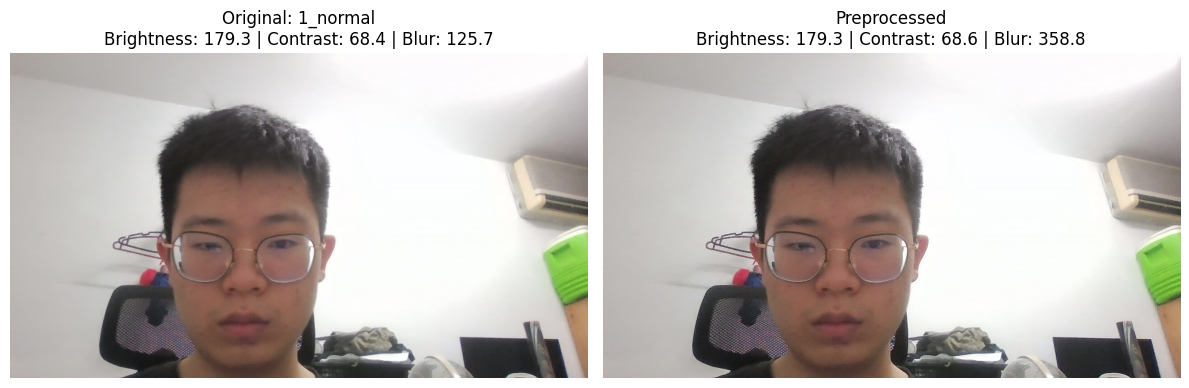


📊 1_normal - Preprocessing Applied:
  - No brightness adjustment needed
  - No contrast adjustment needed
  ✓ Unsharp mask (mild) - blur score was 125.7
  ✓ Bilateral denoise (always applied)
--------------------------------------------------


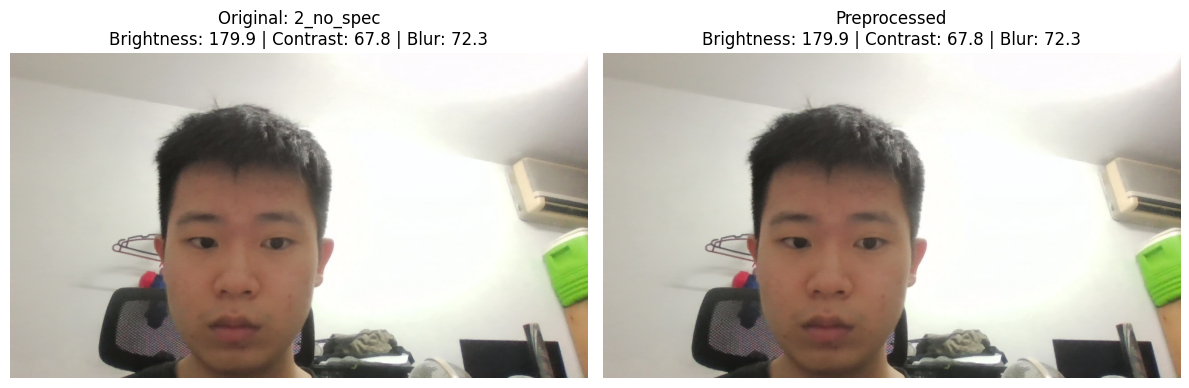


📊 2_no_spec - Preprocessing Applied:
  - No brightness adjustment needed
  - No contrast adjustment needed
  ✓ Unsharp mask (strong) - blur score was 72.3
  ✓ Bilateral denoise (always applied)
--------------------------------------------------

📁 Folder: data/test_set/ch


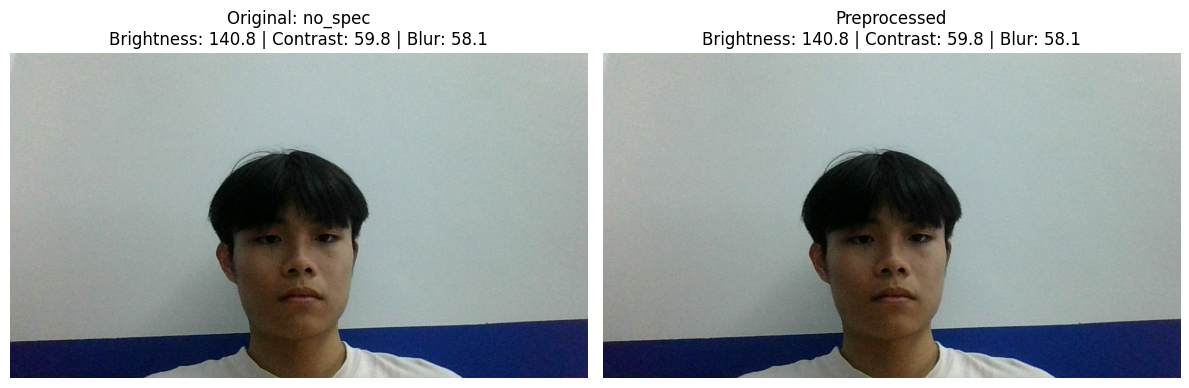


📊 no_spec - Preprocessing Applied:
  - No brightness adjustment needed
  ✓ CLAHE (mild) - contrast was 59.8
  ✓ Unsharp mask (strong) - blur score was 58.1
  ✓ Bilateral denoise (always applied)
--------------------------------------------------


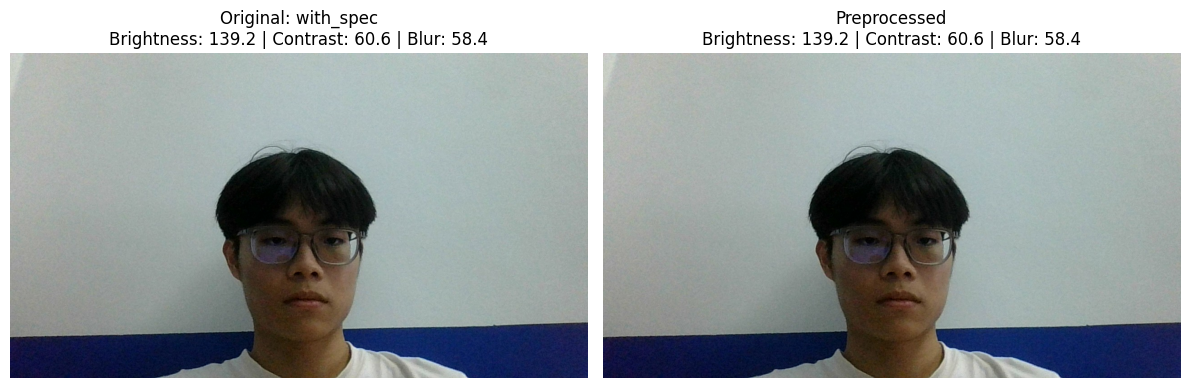


📊 with_spec - Preprocessing Applied:
  - No brightness adjustment needed
  - No contrast adjustment needed
  ✓ Unsharp mask (strong) - blur score was 58.4
  ✓ Bilateral denoise (always applied)
--------------------------------------------------

📁 Folder: data/test_set/hy


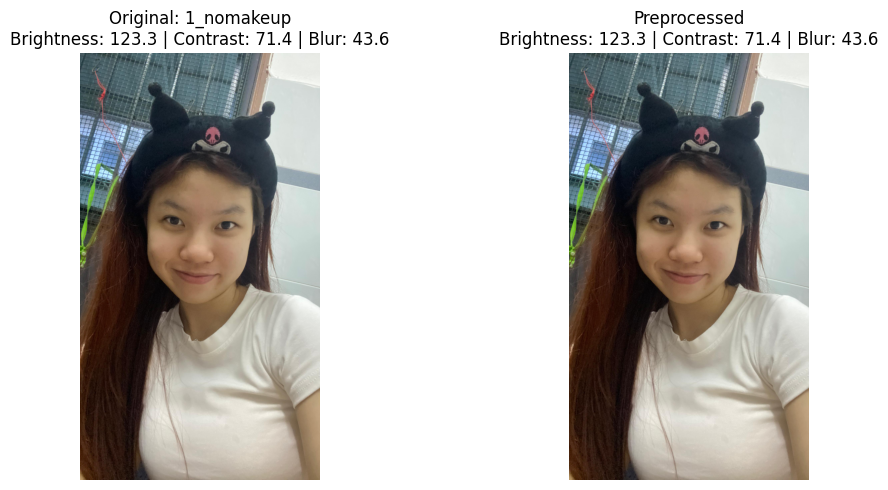


📊 1_nomakeup - Preprocessing Applied:
  - No brightness adjustment needed
  - No contrast adjustment needed
  ✓ Unsharp mask (strong) - blur score was 43.6
  ✓ Bilateral denoise (always applied)
--------------------------------------------------


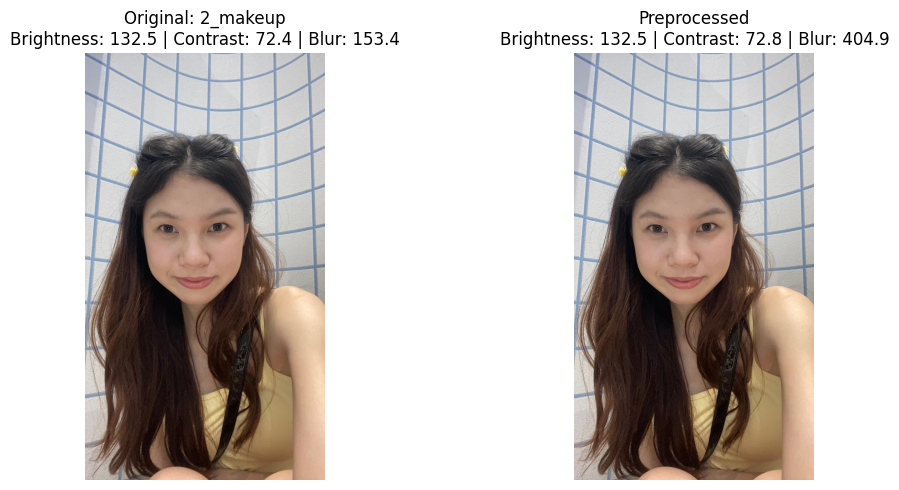


📊 2_makeup - Preprocessing Applied:
  - No brightness adjustment needed
  - No contrast adjustment needed
  ✓ Unsharp mask (mild) - blur score was 153.4
  ✓ Bilateral denoise (always applied)
--------------------------------------------------

📁 Folder: data/test_set/zq


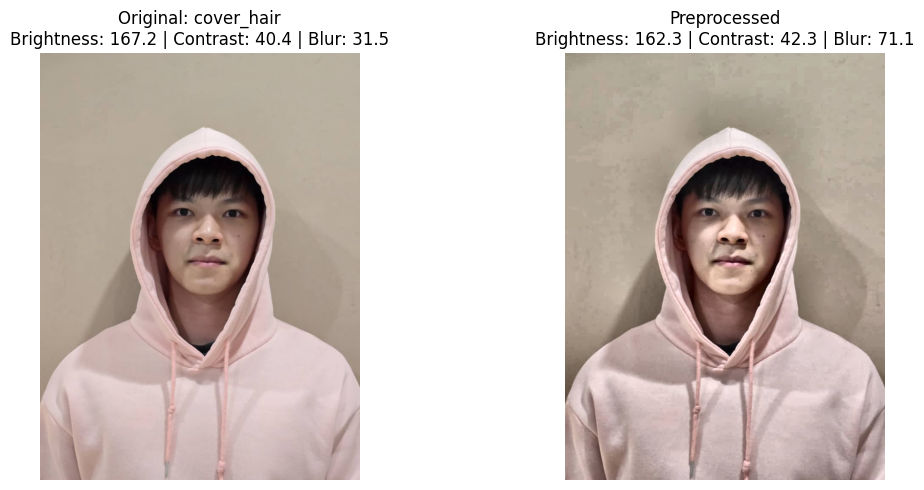


📊 cover_hair - Preprocessing Applied:
  - No brightness adjustment needed
  ✓ CLAHE (mild) - contrast was 40.4
  ✓ Unsharp mask (strong) - blur score was 31.5
  ✓ Bilateral denoise (always applied)
--------------------------------------------------


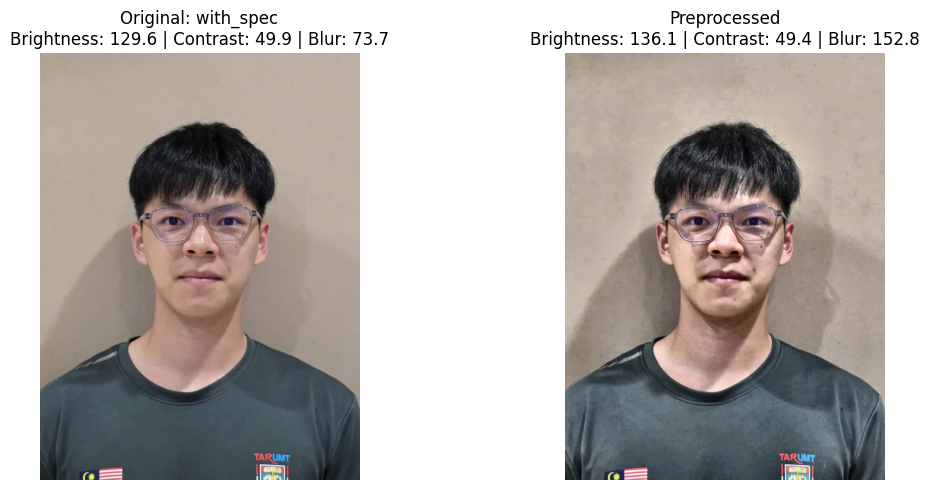


📊 with_spec - Preprocessing Applied:
  - No brightness adjustment needed
  ✓ CLAHE (mild) - contrast was 49.9
  ✓ Unsharp mask (strong) - blur score was 73.7
  ✓ Bilateral denoise (always applied)
--------------------------------------------------


In [25]:
# Cell: Visualize Preprocessing on Test Images

def visualize_preprocessing(test_folder, num_images=5):
    """
    Visualize preprocessing effects on test images
    
    Args:
        test_folder: Path to test images folder
        num_images: Number of images to display
    """
    # Load test images
    test_img_list, img_names = load_img_from_folder(test_folder)
    
    if len(test_img_list) == 0:
        print(f"No images found in {test_folder}")
        return
    
    # Initialize preprocessor
    preprocessor = AdaptivePreprocessor()
    
    # Limit number of images
    num_to_show = min(num_images, len(test_img_list))
    
    for idx in range(num_to_show):
        img = test_img_list[idx]
        img_name = img_names[idx]
        
        # Get image quality metrics
        brightness = preprocessor.estimate_brightness(img)
        contrast = preprocessor.estimate_contrast(img)
        blur_score = preprocessor.estimate_blur(img)
        
        # Apply preprocessing
        processed = preprocessor.process(img)
        
        # Get processed metrics
        brightness_after = preprocessor.estimate_brightness(processed)
        contrast_after = preprocessor.estimate_contrast(processed)
        blur_score_after = preprocessor.estimate_blur(processed)
        
        # Create figure
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        # Original image
        axes[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        axes[0].set_title(f"Original: {img_name}\n"
                         f"Brightness: {brightness:.1f} | Contrast: {contrast:.1f} | Blur: {blur_score:.1f}")
        axes[0].axis('off')
        
        # Processed image
        axes[1].imshow(cv.cvtColor(processed, cv.COLOR_BGR2RGB))
        axes[1].set_title(f"Preprocessed\n"
                         f"Brightness: {brightness_after:.1f} | Contrast: {contrast_after:.1f} | Blur: {blur_score_after:.1f}")
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Print what was applied
        print(f"\n📊 {img_name} - Preprocessing Applied:")
        if brightness < 80:
            print(f"  ✓ Gamma correction (brighten) - brightness was {brightness:.1f}")
        elif brightness > 180:
            print(f"  ✓ Gamma correction (darken) - brightness was {brightness:.1f}")
        else:
            print(f"  - No brightness adjustment needed")
            
        if contrast < 40:
            print(f"  ✓ CLAHE (strong) - contrast was {contrast:.1f}")
        elif contrast < 60:
            print(f"  ✓ CLAHE (mild) - contrast was {contrast:.1f}")
        else:
            print(f"  - No contrast adjustment needed")
            
        if blur_score < 100:
            print(f"  ✓ Unsharp mask (strong) - blur score was {blur_score:.1f}")
        elif blur_score < 300:
            print(f"  ✓ Unsharp mask (mild) - blur score was {blur_score:.1f}")
        else:
            print(f"  - No sharpening needed")
            
        print(f"  ✓ Bilateral denoise (always applied)")
        print("-" * 50)


# Run visualization on each test folder
print("=" * 60)
print("PREPROCESSING VISUALIZATION")
print("=" * 60)

for folder in ["data/test_set/fz", "data/test_set/ch", "data/test_set/hy", "data/test_set/zq"]:
    print(f"\n📁 Folder: {folder}")
    print("=" * 60)
    visualize_preprocessing(folder, num_images=3)

SCENARIO-BASED PREPROCESSING VISUALIZATION


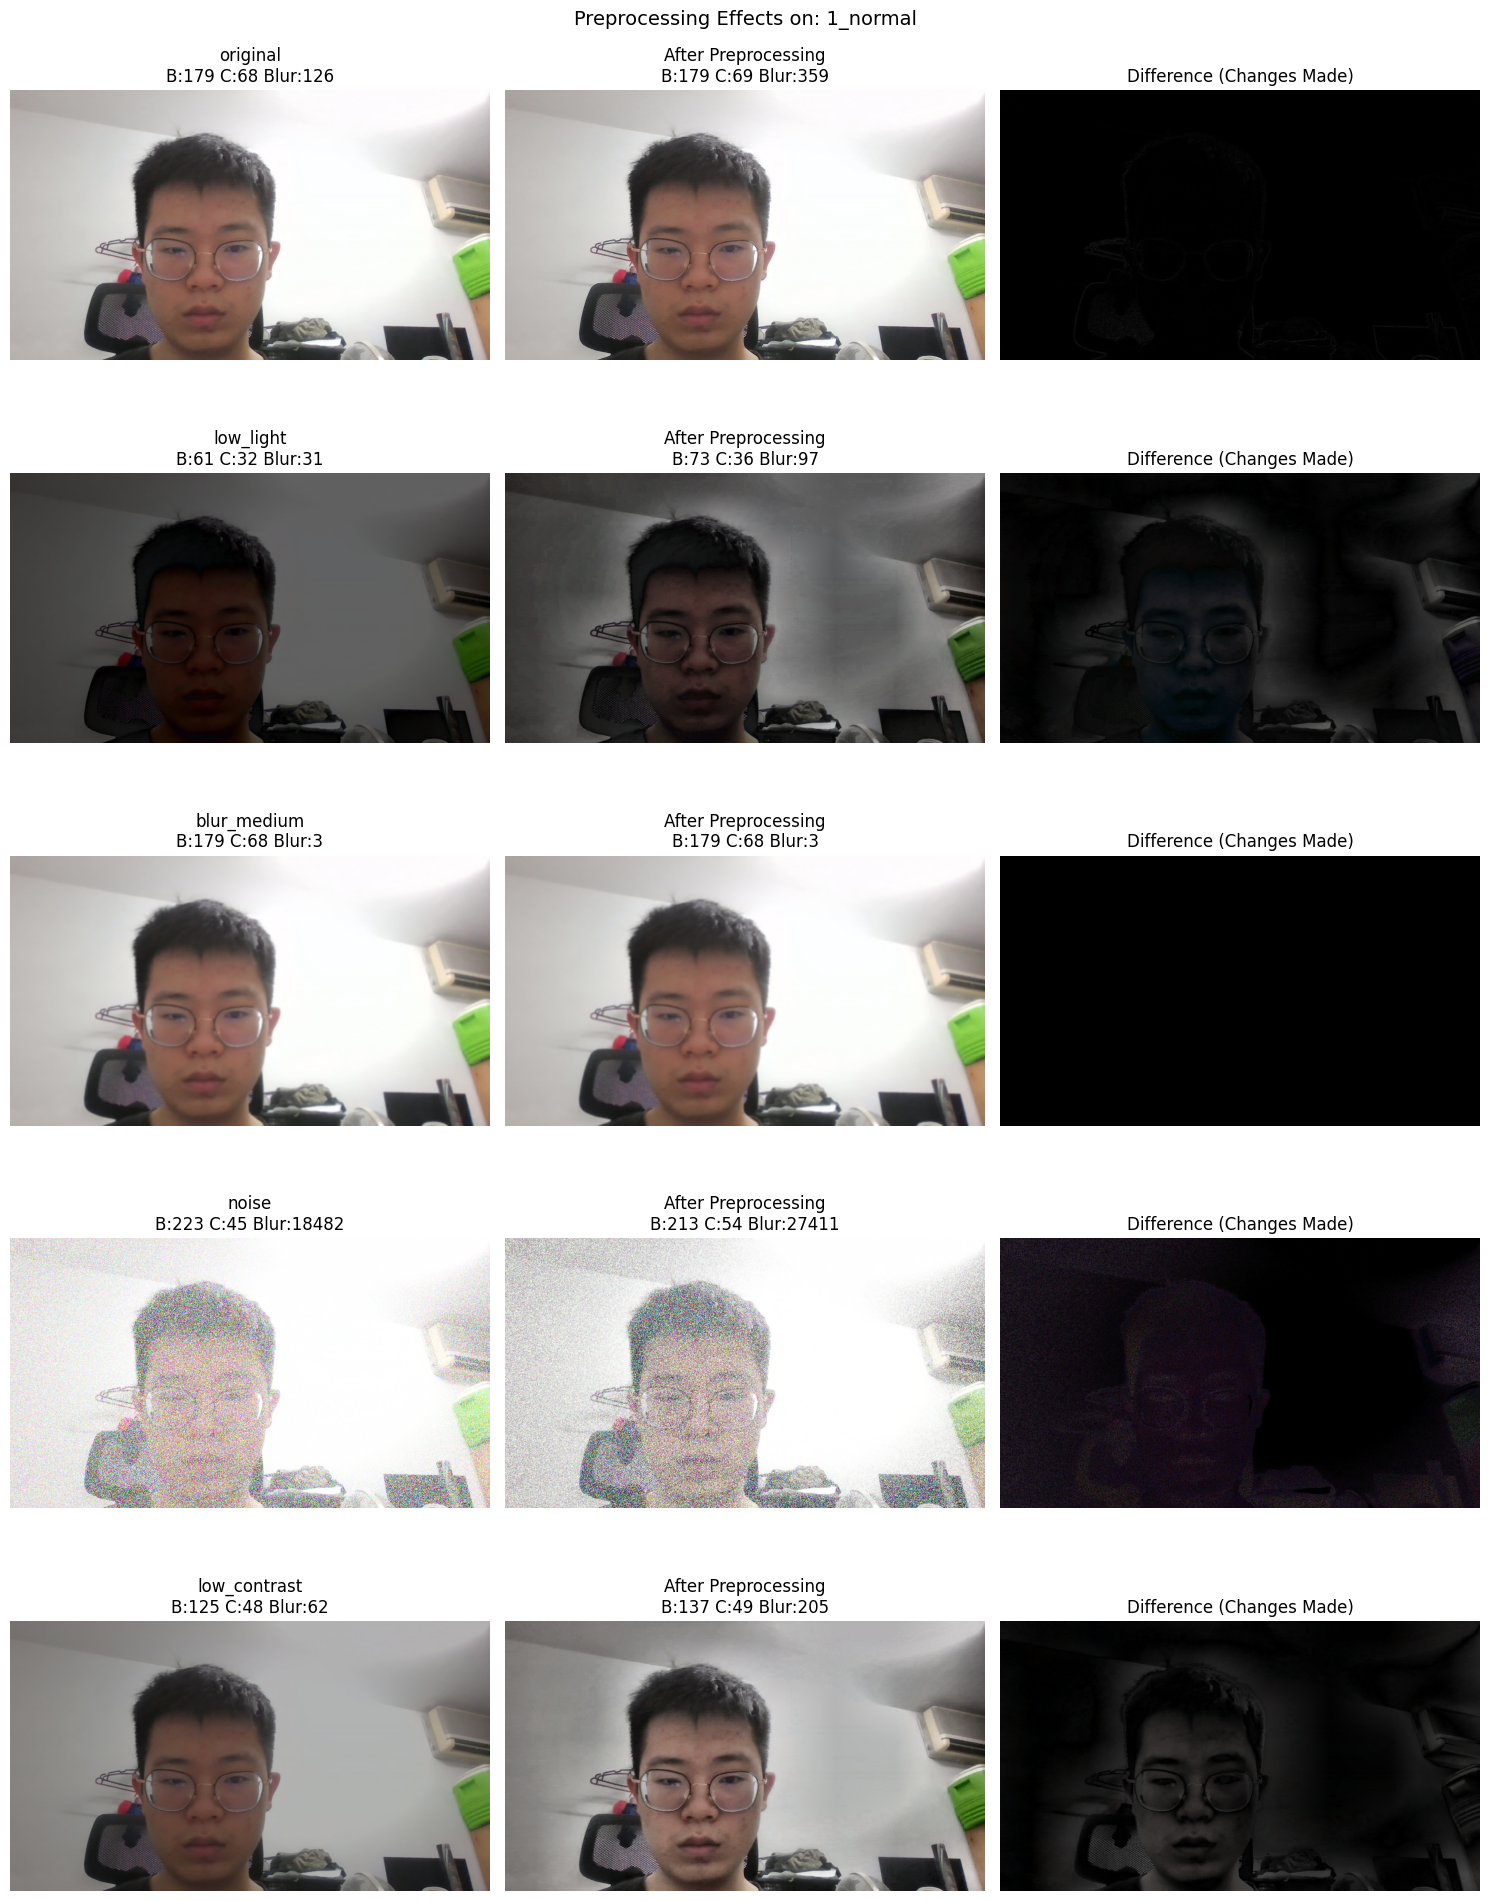

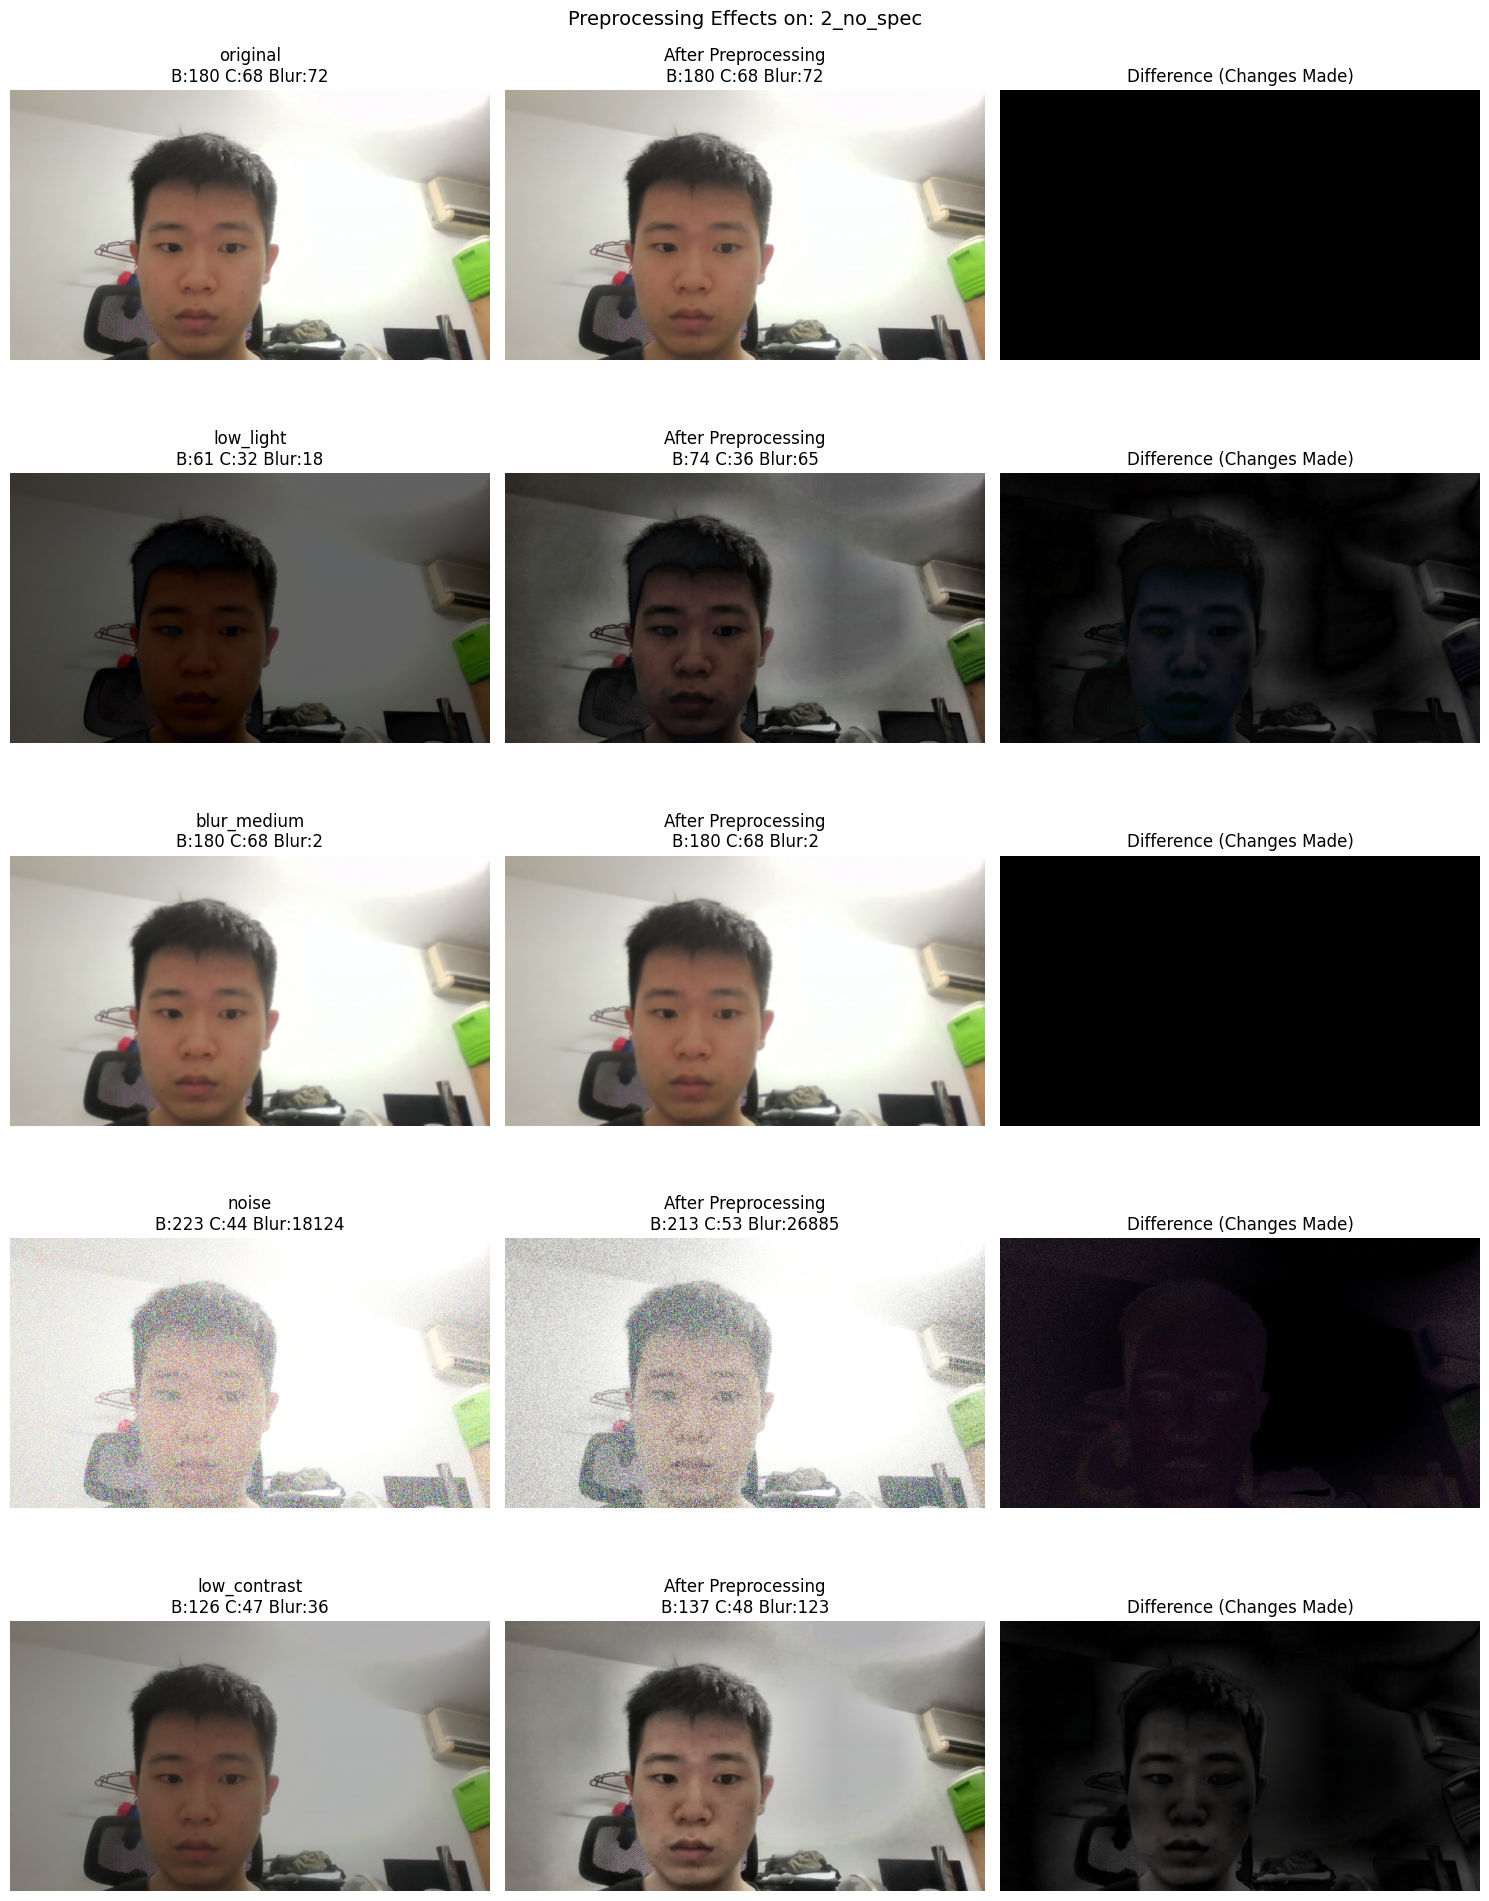

In [26]:
# Cell: Visualize Preprocessing on Augmented Scenarios

def visualize_scenarios_preprocessing(test_folder, num_original=2):
    """
    Visualize preprocessing on augmented scenarios
    """
    test_img_list, img_names = load_img_from_folder(test_folder)
    
    if len(test_img_list) == 0:
        return
    
    preprocessor = AdaptivePreprocessor()
    
    # Process first few images with their scenarios
    for idx in range(min(num_original, len(test_img_list))):
        img = test_img_list[idx]
        img_name = img_names[idx]
        
        # Create scenarios
        scenarios = create_test_scenarios(img)
        
        # Select key scenarios to visualize
        key_scenarios = ['original', 'low_light', 'blur_medium', 'noise', 'low_contrast']
        
        fig, axes = plt.subplots(len(key_scenarios), 3, figsize=(15, 4*len(key_scenarios)))
        
        for row, scenario_name in enumerate(key_scenarios):
            if scenario_name not in scenarios:
                continue
                
            scenario_img = scenarios[scenario_name]
            processed = preprocessor.process(scenario_img)
            
            # Original scenario
            axes[row, 0].imshow(cv.cvtColor(scenario_img, cv.COLOR_BGR2RGB))
            axes[row, 0].set_title(f"{scenario_name}\nB:{preprocessor.estimate_brightness(scenario_img):.0f} "
                                   f"C:{preprocessor.estimate_contrast(scenario_img):.0f} "
                                   f"Blur:{preprocessor.estimate_blur(scenario_img):.0f}")
            axes[row, 0].axis('off')
            
            # Processed
            axes[row, 1].imshow(cv.cvtColor(processed, cv.COLOR_BGR2RGB))
            axes[row, 1].set_title(f"After Preprocessing\nB:{preprocessor.estimate_brightness(processed):.0f} "
                                   f"C:{preprocessor.estimate_contrast(processed):.0f} "
                                   f"Blur:{preprocessor.estimate_blur(processed):.0f}")
            axes[row, 1].axis('off')
            
            # Difference (enhancement visualization)
            diff = cv.absdiff(scenario_img, processed)
            axes[row, 2].imshow(cv.cvtColor(diff, cv.COLOR_BGR2RGB))
            axes[row, 2].set_title("Difference (Changes Made)")
            axes[row, 2].axis('off')
        
        plt.suptitle(f"Preprocessing Effects on: {img_name}", fontsize=14)
        plt.tight_layout()
        plt.show()


# Run on first test folder
print("SCENARIO-BASED PREPROCESSING VISUALIZATION")
visualize_scenarios_preprocessing("data/test_set/fz", num_original=2)

In [27]:
import pandas as pd

def comprehensive_comparison(raw_results_dict, pre_results_dict, test_config):
    """
    Compare Raw vs Preprocessed for all models across multiple metrics
    
    Args:
        raw_results_dict: Dict of {model_name: (results, summaries)} for RAW
        pre_results_dict: Dict of {model_name: (results, summaries)} for PREPROCESSED
        test_config: Test configuration dict
    """
    
    model_names = list(raw_results_dict.keys())
    
    # ============================================
    # 1. OVERALL ACCURACY COMPARISON (Raw vs Preprocessed)
    # ============================================
    print("\n" + "=" * 120)
    print("📊 1. OVERALL ACCURACY COMPARISON (Raw vs Preprocessed)")
    print("=" * 120)
    
    overall_stats = []
    for model_name in model_names:
        # Raw stats
        results_raw, _ = raw_results_dict[model_name]
        total_raw = len(results_raw)
        correct_raw = sum(1 for r in results_raw if r['correct'])
        no_face_raw = sum(1 for r in results_raw if r['pred_id'] == "No Face")
        acc_raw = correct_raw / total_raw * 100  # Including No Face
        
        # Preprocessed stats
        results_pre, _ = pre_results_dict[model_name]
        total_pre = len(results_pre)
        correct_pre = sum(1 for r in results_pre if r['correct'])
        no_face_pre = sum(1 for r in results_pre if r['pred_id'] == "No Face")
        acc_pre = correct_pre / total_pre * 100  # Including No Face
        
        # Improvement
        improvement = acc_pre - acc_raw
        
        overall_stats.append({
            'Model': model_name,
            'Raw Acc': f"{acc_raw:.2f}%",
            'Raw NoFace': no_face_raw,
            'Pre Acc': f"{acc_pre:.2f}%",
            'Pre NoFace': no_face_pre,
            'Improvement': f"{improvement:+.2f}%"
        })
    
    df_overall = pd.DataFrame(overall_stats)
    print(df_overall.to_string(index=False))
    
    # ============================================
    # 2. FALSE POSITIVE RATE (Raw vs Preprocessed)
    # ============================================
    print("\n" + "=" * 120)
    print("📊 2. FALSE POSITIVE RATE COMPARISON (Raw vs Preprocessed)")
    print("=" * 120)
    print("FPR = Wrong Matches / (Total - No Face Detected) → Lower is Better\n")
    
    fpr_stats = []
    for model_name in model_names:
        # Raw FPR
        results_raw, _ = raw_results_dict[model_name]
        total_raw = len(results_raw)
        no_face_raw = sum(1 for r in results_raw if r['pred_id'] == "No Face")
        wrong_raw = sum(1 for r in results_raw if r['pred_id'] not in ["No Face", "Not Matched", None] and not r['correct'])
        detected_raw = total_raw - no_face_raw
        fpr_raw = wrong_raw / detected_raw * 100 if detected_raw > 0 else 0
        
        # Preprocessed FPR
        results_pre, _ = pre_results_dict[model_name]
        total_pre = len(results_pre)
        no_face_pre = sum(1 for r in results_pre if r['pred_id'] == "No Face")
        wrong_pre = sum(1 for r in results_pre if r['pred_id'] not in ["No Face", "Not Matched", None] and not r['correct'])
        detected_pre = total_pre - no_face_pre
        fpr_pre = wrong_pre / detected_pre * 100 if detected_pre > 0 else 0
        
        # Improvement (negative is better for FPR)
        improvement = fpr_raw - fpr_pre  # Positive means preprocessing reduced FPR
        
        fpr_stats.append({
            'Model': model_name,
            'Raw FPR': f"{fpr_raw:.2f}%",
            'Raw FP Count': wrong_raw,
            'Pre FPR': f"{fpr_pre:.2f}%",
            'Pre FP Count': wrong_pre,
            'FPR Reduction': f"{improvement:+.2f}%"
        })
    
    df_fpr = pd.DataFrame(fpr_stats)
    print(df_fpr.to_string(index=False))
    
    # ============================================
    # 3. ACCURACY BY NOISE TYPE (Raw vs Preprocessed)
    # ============================================
    print("\n" + "=" * 120)
    print("📊 3. ACCURACY BY NOISE TYPE (Raw vs Preprocessed)")
    print("=" * 120)
    
    augmented_scenarios = {
        'blur_light': 'Blur (Light)',
        'blur_medium': 'Blur (Medium)',
        'blur_heavy': 'Blur (Heavy)',
        'motion_blur': 'Motion Blur',
        'noise': 'Gaussian Noise',
        'low_light': 'Low Light',
        'high_light': 'High Light',
        'low_contrast': 'Low Contrast',
        'high_contrast': 'High Contrast',
        'jpeg_compressed': 'JPEG Compression',
        'rotated_10': 'Rotation (10°)',
        'zoomed': 'Zoomed',
        'cropped_tight': 'Cropped (Tight)',
        'cropped_padded': 'Cropped (Padded)'
    }
    
    def extract_scenario(test_name):
        for scenario_key in augmented_scenarios.keys():
            if test_name.endswith('_' + scenario_key):
                return scenario_key
        return 'original'
    
    def build_scenario_stats(results_dict):
        scenario_comparison = {scenario: {} for scenario in augmented_scenarios.keys()}
        for model_name, (results, _) in results_dict.items():
            for r in results:
                scenario = extract_scenario(r['test_name'])
                if scenario == 'original' or scenario not in augmented_scenarios:
                    continue
                if model_name not in scenario_comparison[scenario]:
                    scenario_comparison[scenario][model_name] = {'total': 0, 'correct': 0, 'no_face': 0}
                scenario_comparison[scenario][model_name]['total'] += 1
                if r['correct']:
                    scenario_comparison[scenario][model_name]['correct'] += 1
                if r['pred_id'] == 'No Face':
                    scenario_comparison[scenario][model_name]['no_face'] += 1
        return scenario_comparison
    
    raw_scenario = build_scenario_stats(raw_results_dict)
    pre_scenario = build_scenario_stats(pre_results_dict)
    
    # Build comparison table
    scenario_rows = []
    for scenario_key, scenario_label in augmented_scenarios.items():
        has_data = any(model in raw_scenario[scenario_key] and raw_scenario[scenario_key][model]['total'] > 0 
                      for model in model_names)
        if not has_data:
            continue
        
        row = {'Noise Type': scenario_label}
        for model in model_names:
            # Raw accuracy
            if model in raw_scenario[scenario_key] and raw_scenario[scenario_key][model]['total'] > 0:
                data_raw = raw_scenario[scenario_key][model]
                acc_raw = data_raw['correct'] / data_raw['total'] * 100
            else:
                acc_raw = 0
            
            # Preprocessed accuracy
            if model in pre_scenario[scenario_key] and pre_scenario[scenario_key][model]['total'] > 0:
                data_pre = pre_scenario[scenario_key][model]
                acc_pre = data_pre['correct'] / data_pre['total'] * 100
            else:
                acc_pre = 0
            
            row[f'{model[:8]} Raw'] = f"{acc_raw:.1f}%"
            row[f'{model[:8]} Pre'] = f"{acc_pre:.1f}%"
        
        scenario_rows.append(row)
    
    df_scenario = pd.DataFrame(scenario_rows)
    print(df_scenario.to_string(index=False))
    
    # ============================================
    # 4. ACCURACY BY FOLDER/SUBJECT (Raw vs Preprocessed)
    # ============================================
    print("\n" + "=" * 120)
    print("📊 4. ACCURACY BY FOLDER/SUBJECT (Raw vs Preprocessed)")
    print("=" * 120)
    
    folder_comparison = {}
    
    # Raw folder stats
    for model_name, (results, summaries) in raw_results_dict.items():
        for summary in summaries:
            folder = summary['folder'].split('/')[-1]
            if folder not in folder_comparison:
                folder_comparison[folder] = {}
            if model_name not in folder_comparison[folder]:
                folder_comparison[folder][model_name] = {}
            folder_comparison[folder][model_name]['raw_acc'] = summary['accuracy']
            folder_comparison[folder][model_name]['raw_noface'] = summary['no_face']
    
    # Preprocessed folder stats
    for model_name, (results, summaries) in pre_results_dict.items():
        for summary in summaries:
            folder = summary['folder'].split('/')[-1]
            if folder not in folder_comparison:
                folder_comparison[folder] = {}
            if model_name not in folder_comparison[folder]:
                folder_comparison[folder][model_name] = {}
            folder_comparison[folder][model_name]['pre_acc'] = summary['accuracy']
            folder_comparison[folder][model_name]['pre_noface'] = summary['no_face']
    
    print(f"\n{'Folder':<10}", end="")
    for model in model_names:
        print(f" | {model[:10]:^10} Raw | Pre", end="")
    print()
    print("-" * (10 + len(model_names) * 24))
    
    for folder in sorted(folder_comparison.keys()):
        print(f"{folder:<10}", end="")
        for model in model_names:
            if model in folder_comparison[folder]:
                data = folder_comparison[folder][model]
                raw_acc = data.get('raw_acc', 0)
                pre_acc = data.get('pre_acc', 0)
                print(f" | {raw_acc:>8.1f}% | {pre_acc:.1f}%", end="")
            else:
                print(f" | {'N/A':>8} | {'N/A'}", end="")
        print()
    
    # ============================================
    # 5. SCENARIO ACCURACY MATRICES (Raw and Preprocessed)
    # ============================================
    print("\n" + "=" * 120)
    print("📊 5. SCENARIO ACCURACY MATRIX - RAW")
    print("=" * 120)
    
    def build_matrix(scenario_stats):
        matrix = []
        labels = []
        for scenario_key, scenario_label in augmented_scenarios.items():
            has_data = any(model in scenario_stats[scenario_key] and scenario_stats[scenario_key][model]['total'] > 0 
                          for model in model_names)
            if not has_data:
                continue
            labels.append(scenario_label)
            row = [scenario_label]
            for model in model_names:
                if model in scenario_stats[scenario_key] and scenario_stats[scenario_key][model]['total'] > 0:
                    data = scenario_stats[scenario_key][model]
                    acc = data['correct'] / data['total'] * 100
                    row.append(round(acc, 1))
                else:
                    row.append(0)
            matrix.append(row)
        return matrix, labels
    
    raw_matrix, scenario_labels = build_matrix(raw_scenario)
    df_raw_matrix = pd.DataFrame(raw_matrix, columns=['Noise Type'] + model_names)
    print(df_raw_matrix.to_string(index=False))
    
    print("\n" + "=" * 120)
    print("📊 5. SCENARIO ACCURACY MATRIX - PREPROCESSED")
    print("=" * 120)
    
    pre_matrix, _ = build_matrix(pre_scenario)
    df_pre_matrix = pd.DataFrame(pre_matrix, columns=['Noise Type'] + model_names)
    print(df_pre_matrix.to_string(index=False))
    
    return df_overall, df_fpr, df_scenario, df_raw_matrix, df_pre_matrix

In [28]:

# Raw results (no preprocessing)
raw_results_dict = {
    'HOG+Dlib': (raw_hog_results, raw_hog_summaries),
    'DeepFace': (raw_deepface_results, raw_deepface_summaries),
    'MTCNN+FaceNet': (raw_mtcnn_results, raw_mtcnn_summaries),
    'InsightFace': (raw_insightface_results, raw_insightface_summaries)
}

# Preprocessed results
pre_results_dict = {
    'HOG+Dlib': (pre_hog_results, pre_hog_summaries),
    'DeepFace': (pre_deepface_results, pre_deepface_summaries),
    'MTCNN+FaceNet': (pre_mtcnn_results, pre_mtcnn_summaries),
    'InsightFace': (pre_insightface_results, pre_insightface_summaries)
}

# Run comparison
df_overall, df_fpr, df_scenario, df_raw_matrix, df_pre_matrix = comprehensive_comparison(
    raw_results_dict, pre_results_dict, test_config
)


📊 1. OVERALL ACCURACY COMPARISON (Raw vs Preprocessed)
        Model Raw Acc  Raw NoFace Pre Acc  Pre NoFace Improvement
     HOG+Dlib  89.17%          11  90.83%           8      +1.67%
     DeepFace  79.17%          23  80.00%          21      +0.83%
MTCNN+FaceNet  79.17%          12  75.83%          14      -3.33%
  InsightFace  78.33%          21  78.33%          22      +0.00%

📊 2. FALSE POSITIVE RATE COMPARISON (Raw vs Preprocessed)
FPR = Wrong Matches / (Total - No Face Detected) → Lower is Better

        Model Raw FPR  Raw FP Count Pre FPR  Pre FP Count FPR Reduction
     HOG+Dlib   1.83%             2   1.79%             2        +0.05%
     DeepFace   2.06%             2   3.03%             3        -0.97%
MTCNN+FaceNet  12.04%            13  14.15%            15        -2.11%
  InsightFace   0.00%             0   0.00%             0        +0.00%

📊 3. ACCURACY BY NOISE TYPE (Raw vs Preprocessed)
      Noise Type HOG+Dlib Raw HOG+Dlib Pre DeepFace Raw DeepFace Pre MTCNN+F

In [29]:
# Cell: Visual Charts - Raw vs Preprocessed Comparison

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def plot_comparison_charts(raw_results_dict, pre_results_dict):
    """
    Create visual charts comparing Raw vs Preprocessed for each algorithm
    
    Args:
        raw_results_dict: Dict of {model_name: (results, summaries)} for RAW
        pre_results_dict: Dict of {model_name: (results, summaries)} for PREPROCESSED
    """
    
    model_names = list(raw_results_dict.keys())
    
    # ============================================
    # CHART 1: OVERALL ACCURACY - Raw vs Preprocessed (Horizontal)
    # ============================================
    print("=" * 70)
    print("📊 CHART 1: OVERALL ACCURACY COMPARISON (Raw vs Preprocessed)")
    print("=" * 70)
    
    raw_acc = []
    pre_acc = []
    
    for model_name in model_names:
        # Raw accuracy (INCLUDING No Face)
        results_raw, _ = raw_results_dict[model_name]
        total = len(results_raw)
        correct = sum(1 for r in results_raw if r['correct'])
        raw_acc.append(correct / total * 100 if total > 0 else 0)
        
        # Preprocessed accuracy (INCLUDING No Face)
        results_pre, _ = pre_results_dict[model_name]
        total = len(results_pre)
        correct = sum(1 for r in results_pre if r['correct'])
        pre_acc.append(correct / total * 100 if total > 0 else 0)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    y = np.arange(len(model_names))
    height = 0.35
    
    bars1 = ax.barh(y - height/2, raw_acc, height, label='Raw', color='#3498db')
    bars2 = ax.barh(y + height/2, pre_acc, height, label='Preprocessed', color='#2ecc71')
    
    ax.set_ylabel('Model', fontsize=12)
    ax.set_xlabel('Accuracy (%)', fontsize=12)
    ax.set_title('1. Overall Accuracy: Raw vs Preprocessed (Including No Face)', fontsize=14, fontweight='bold')
    ax.set_yticks(y)
    ax.set_yticklabels(model_names, fontsize=11)
    ax.legend(fontsize=10, loc='lower right')
    ax.set_xlim(0, 110)
    ax.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for bar in bars1:
        width = bar.get_width()
        ax.annotate(f'{width:.1f}%', xy=(width, bar.get_y() + bar.get_height()/2),
                    ha='left', va='center', fontsize=10, fontweight='bold')
    for bar in bars2:
        width = bar.get_width()
        ax.annotate(f'{width:.1f}%', xy=(width, bar.get_y() + bar.get_height()/2),
                    ha='left', va='center', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # ============================================
    # CHART 2: FALSE POSITIVE RATE - Raw vs Preprocessed (Horizontal)
    # ============================================
    print("\n" + "=" * 70)
    print("📊 CHART 2: FALSE POSITIVE RATE (Raw vs Preprocessed)")
    print("=" * 70)
    
    raw_fpr = []
    pre_fpr = []
    
    for model_name in model_names:
        # Raw FPR
        results_raw, _ = raw_results_dict[model_name]
        total = len(results_raw)
        no_face = sum(1 for r in results_raw if r['pred_id'] == "No Face")
        wrong = sum(1 for r in results_raw if r['pred_id'] not in ["No Face", "Not Matched", None] and not r['correct'])
        detected = total - no_face
        raw_fpr.append(wrong / detected * 100 if detected > 0 else 0)
        
        # Preprocessed FPR
        results_pre, _ = pre_results_dict[model_name]
        total = len(results_pre)
        no_face = sum(1 for r in results_pre if r['pred_id'] == "No Face")
        wrong = sum(1 for r in results_pre if r['pred_id'] not in ["No Face", "Not Matched", None] and not r['correct'])
        detected = total - no_face
        pre_fpr.append(wrong / detected * 100 if detected > 0 else 0)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    y = np.arange(len(model_names))
    height = 0.35
    
    bars1 = ax.barh(y - height/2, raw_fpr, height, label='Raw', color='#e74c3c')
    bars2 = ax.barh(y + height/2, pre_fpr, height, label='Preprocessed', color='#f39c12')
    
    ax.set_ylabel('Model', fontsize=12)
    ax.set_xlabel('False Positive Rate (%)', fontsize=12)
    ax.set_title('2. False Positive Rate: Raw vs Preprocessed (Lower is Better)', fontsize=14, fontweight='bold')
    ax.set_yticks(y)
    ax.set_yticklabels(model_names, fontsize=11)
    ax.legend(fontsize=10, loc='lower right')
    ax.set_xlim(0, max(max(raw_fpr), max(pre_fpr)) * 1.3 + 5)
    ax.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for bar in bars1:
        width = bar.get_width()
        ax.annotate(f'{width:.1f}%', xy=(width, bar.get_y() + bar.get_height()/2),
                    ha='left', va='center', fontsize=10, fontweight='bold')
    for bar in bars2:
        width = bar.get_width()
        ax.annotate(f'{width:.1f}%', xy=(width, bar.get_y() + bar.get_height()/2),
                    ha='left', va='center', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # ============================================
    # CHART 3: HEATMAPS - Raw vs Preprocessed (Side by Side)
    # ============================================
    print("\n" + "=" * 70)
    print("📊 CHART 3: SCENARIO ACCURACY HEATMAPS (Raw vs Preprocessed)")
    print("=" * 70)
    
    # Define augmented scenarios
    augmented_scenarios = {
        'blur_light': 'Blur (Light)',
        'blur_medium': 'Blur (Medium)',
        'blur_heavy': 'Blur (Heavy)',
        'motion_blur': 'Motion Blur',
        'noise': 'Gaussian Noise',
        'low_light': 'Low Light',
        'high_light': 'High Light',
        'low_contrast': 'Low Contrast',
        'high_contrast': 'High Contrast',
        'jpeg_compressed': 'JPEG Compress',
        'rotated_10': 'Rotation (10°)',
        'zoomed': 'Zoomed',
        'cropped_tight': 'Crop (Tight)',
        'cropped_padded': 'Crop (Padded)'
    }
    
    def extract_scenario(test_name):
        for scenario_key in augmented_scenarios.keys():
            if test_name.endswith('_' + scenario_key):
                return scenario_key
        return 'original'
    
    def build_scenario_matrix(results_dict):
        scenario_comparison = {scenario: {} for scenario in augmented_scenarios.keys()}
        
        for model_name, (results, _) in results_dict.items():
            for r in results:
                scenario = extract_scenario(r['test_name'])
                if scenario == 'original' or scenario not in augmented_scenarios:
                    continue
                
                if model_name not in scenario_comparison[scenario]:
                    scenario_comparison[scenario][model_name] = {'total': 0, 'correct': 0}
                
                scenario_comparison[scenario][model_name]['total'] += 1
                if r['correct']:
                    scenario_comparison[scenario][model_name]['correct'] += 1
        
        scenario_labels = []
        matrix_data = []
        
        for scenario_key, scenario_label in augmented_scenarios.items():
            has_data = any(model in scenario_comparison[scenario_key] and 
                          scenario_comparison[scenario_key][model]['total'] > 0 
                          for model in model_names)
            if not has_data:
                continue
            
            scenario_labels.append(scenario_label)
            row = []
            for model in model_names:
                if model in scenario_comparison[scenario_key]:
                    data = scenario_comparison[scenario_key][model]
                    acc = data['correct'] / data['total'] * 100 if data['total'] > 0 else 0
                    row.append(round(acc, 1))
                else:
                    row.append(0)
            matrix_data.append(row)
        
        return np.array(matrix_data), scenario_labels
    
    # Build matrices
    raw_matrix, scenario_labels = build_scenario_matrix(raw_results_dict)
    pre_matrix, _ = build_scenario_matrix(pre_results_dict)
    
    # ============================================
    # CHART 3A: RAW HEATMAP (Separate)
    # ============================================
    print("\n" + "=" * 70)
    print("📊 CHART 3A: SCENARIO ACCURACY HEATMAP - RAW (No Preprocessing)")
    print("=" * 70)
    
    fig1, ax1 = plt.subplots(figsize=(10, 10))
    
    im1 = ax1.imshow(raw_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
    ax1.set_xticks(np.arange(len(model_names)))
    ax1.set_yticks(np.arange(len(scenario_labels)))
    ax1.set_xticklabels(model_names, fontsize=11)
    ax1.set_yticklabels(scenario_labels, fontsize=10)
    plt.setp(ax1.get_xticklabels(), rotation=20, ha='right')
    ax1.set_title('3A. Scenario Accuracy Heatmap - RAW (No Preprocessing)\n(Green = High Accuracy, Red = Low Accuracy)', 
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel('Model', fontsize=12)
    ax1.set_ylabel('Noise Type', fontsize=12)
    
    # Add annotations for raw
    for i in range(len(scenario_labels)):
        for j in range(len(model_names)):
            value = raw_matrix[i, j]
            text_color = 'white' if value < 50 else 'black'
            ax1.text(j, i, f'{value:.0f}%', ha='center', va='center', 
                    color=text_color, fontsize=10, fontweight='bold')
    
    fig1.colorbar(im1, ax=ax1, shrink=0.6, label='Accuracy (%)')
    plt.tight_layout()
    plt.show()
    
    # ============================================
    # CHART 3B: PREPROCESSED HEATMAP (Separate)
    # ============================================
    print("\n" + "=" * 70)
    print("📊 CHART 3B: SCENARIO ACCURACY HEATMAP - PREPROCESSED")
    print("=" * 70)
    
    fig2, ax2 = plt.subplots(figsize=(10, 10))
    
    im2 = ax2.imshow(pre_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
    ax2.set_xticks(np.arange(len(model_names)))
    ax2.set_yticks(np.arange(len(scenario_labels)))
    ax2.set_xticklabels(model_names, fontsize=11)
    ax2.set_yticklabels(scenario_labels, fontsize=10)
    plt.setp(ax2.get_xticklabels(), rotation=20, ha='right')
    ax2.set_title('3B. Scenario Accuracy Heatmap - PREPROCESSED\n(Green = High Accuracy, Red = Low Accuracy)', 
                  fontsize=14, fontweight='bold')
    ax2.set_xlabel('Model', fontsize=12)
    ax2.set_ylabel('Noise Type', fontsize=12)
    
    # Add annotations for preprocessed
    for i in range(len(scenario_labels)):
        for j in range(len(model_names)):
            value = pre_matrix[i, j]
            text_color = 'white' if value < 50 else 'black'
            ax2.text(j, i, f'{value:.0f}%', ha='center', va='center', 
                    color=text_color, fontsize=10, fontweight='bold')
    
    fig2.colorbar(im2, ax=ax2, shrink=0.6, label='Accuracy (%)')
    plt.tight_layout()
    plt.show()
    
    return

📊 CHART 1: OVERALL ACCURACY COMPARISON (Raw vs Preprocessed)


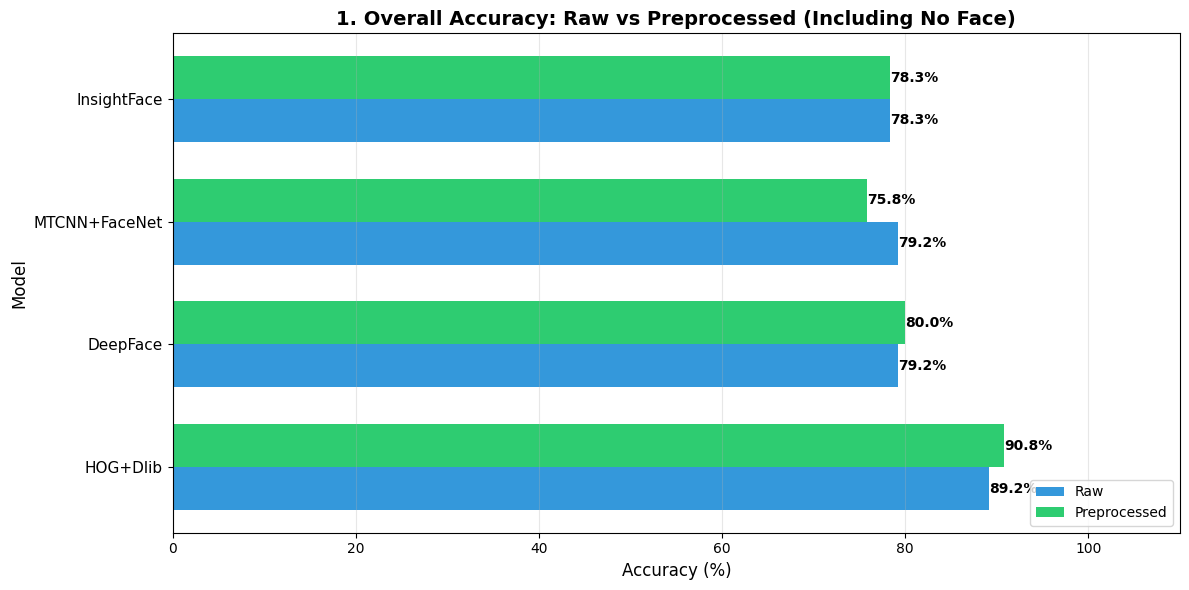


📊 CHART 2: FALSE POSITIVE RATE (Raw vs Preprocessed)


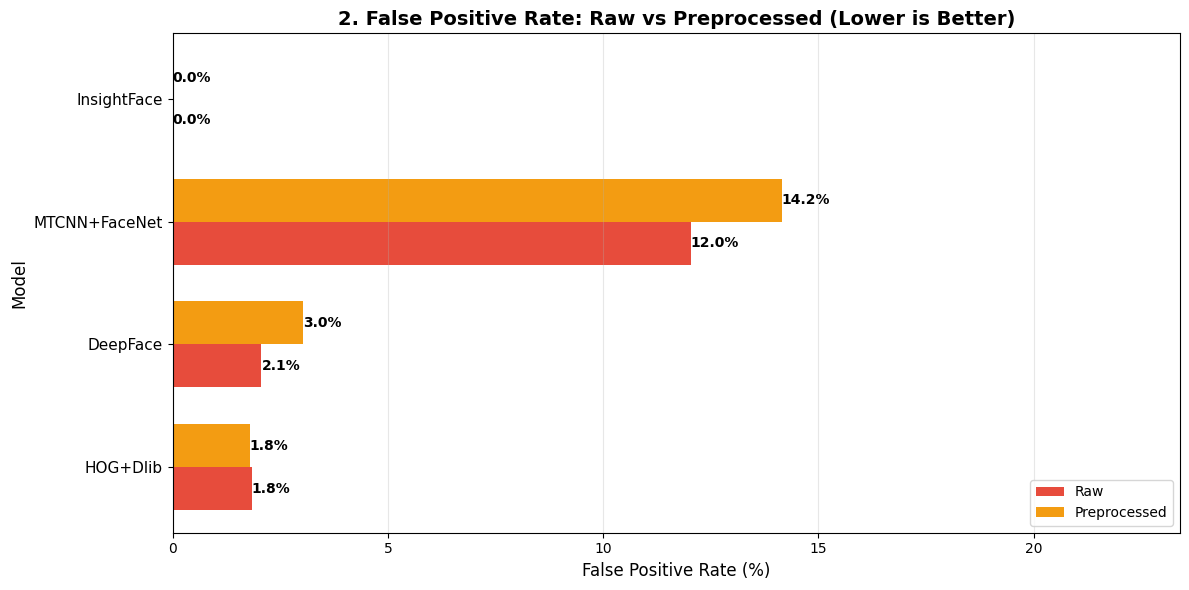


📊 CHART 3: SCENARIO ACCURACY HEATMAPS (Raw vs Preprocessed)

📊 CHART 3A: SCENARIO ACCURACY HEATMAP - RAW (No Preprocessing)


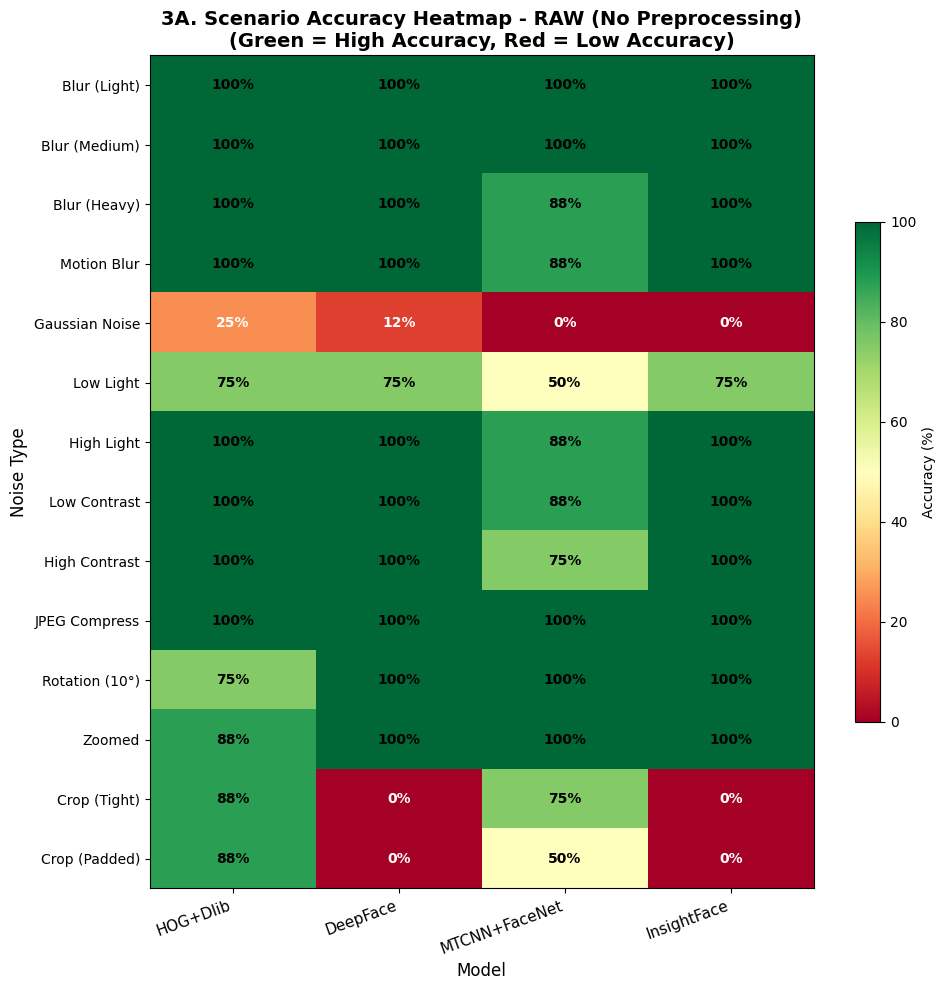


📊 CHART 3B: SCENARIO ACCURACY HEATMAP - PREPROCESSED


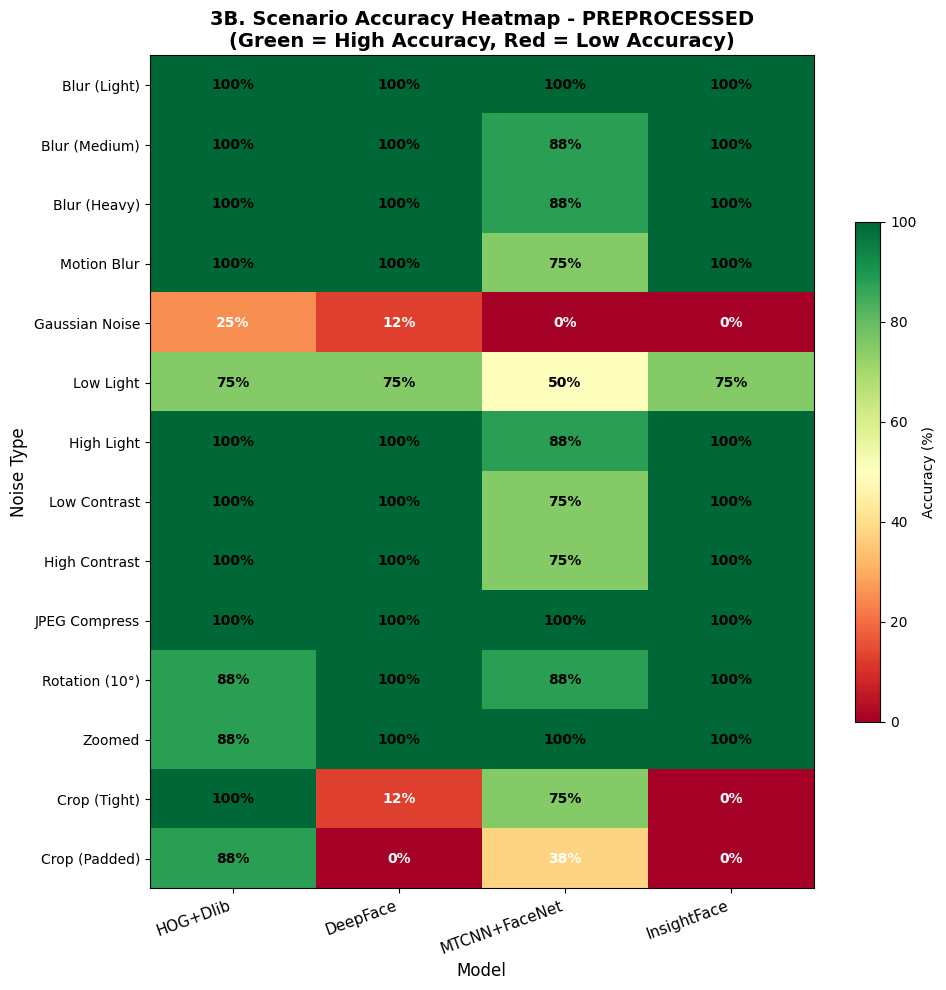

In [30]:
# Cell: Organize Results

# Raw results (no preprocessing)
raw_results_dict = {
    'HOG+Dlib': (raw_hog_results, raw_hog_summaries),
    'DeepFace': (raw_deepface_results, raw_deepface_summaries),
    'MTCNN+FaceNet': (raw_mtcnn_results, raw_mtcnn_summaries),
    'InsightFace': (raw_insightface_results, raw_insightface_summaries)
}

# Preprocessed results
pre_results_dict = {
    'HOG+Dlib': (pre_hog_results, pre_hog_summaries),
    'DeepFace': (pre_deepface_results, pre_deepface_summaries),
    'MTCNN+FaceNet': (pre_mtcnn_results, pre_mtcnn_summaries),
    'InsightFace': (pre_insightface_results, pre_insightface_summaries)
}

# Run the comparison charts
plot_comparison_charts(raw_results_dict, pre_results_dict)

In [31]:
import cv2 as cv
import numpy as np
from pyzbar import pyzbar
import qrcode

class QRCodeScanner:
    """QR Code Scanner and Generator for images"""
    
    def __init__(self):
        self.cv_detector = cv.QRCodeDetector()
    
    # ==================== GENERATION ====================
    
    def generate(self, data, size=300, border=4, error_correction='M'):
        """
        Generate QR code image
        
        Args:
            data: String data to encode
            size: Output image size in pixels
            border: Border size (minimum 4)
            error_correction: 'L' (7%), 'M' (15%), 'Q' (25%), 'H' (30%)
        
        Returns:
            QR code as numpy array (BGR)
        """
        # Error correction levels
        ec_levels = {
            'L': qrcode.constants.ERROR_CORRECT_L,
            'M': qrcode.constants.ERROR_CORRECT_M,
            'Q': qrcode.constants.ERROR_CORRECT_Q,
            'H': qrcode.constants.ERROR_CORRECT_H
        }
        
        qr = qrcode.QRCode(
            version=1,
            error_correction=ec_levels.get(error_correction, qrcode.constants.ERROR_CORRECT_M),
            box_size=10,
            border=border
        )
        qr.add_data(data)
        qr.make(fit=True)
        
        # Create PIL image and convert to numpy
        pil_img = qr.make_image(fill_color="black", back_color="white")
        img = np.array(pil_img.convert('RGB'))
        img = cv.cvtColor(img, cv.COLOR_RGB2BGR)
        
        # Resize to desired size
        img = cv.resize(img, (size, size), interpolation=cv.INTER_NEAREST)
        
        return img
    
    def generate_and_save(self, data, output_path, size=300, border=4):
        """
        Generate QR code and save to file
        
        Args:
            data: String data to encode
            output_path: Path to save image
            size: Output image size in pixels
            border: Border size
        
        Returns:
            True if successful
        """
        img = self.generate(data, size, border)
        success = cv.imwrite(output_path, img)
        
        if success:
            print(f"✓ QR code saved: {output_path}")
        else:
            print(f"✗ Failed to save: {output_path}")
        
        return success
    
    # ==================== PREPROCESSING ====================
    
    def preprocess(self, frame):
        """Preprocess image for better QR detection"""
        # 1. Convert to Grayscale
        gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
        
        # 2. Apply Gaussian Blur
        blurred = cv.GaussianBlur(gray, (5, 5), 0)
        
        # 3. Adaptive Thresholding
        binary = cv.adaptiveThreshold(
            blurred, 255,
            cv.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv.THRESH_BINARY, 11, 2
        )
        return binary
    
    def enhance_image(self, image, scale=2.0):
        """Enhance and upscale image for better QR detection"""
        # Upscale
        h, w = image.shape[:2]
        new_w, new_h = int(w * scale), int(h * scale)
        upscaled = cv.resize(image, (new_w, new_h), interpolation=cv.INTER_CUBIC)
        
        # Sharpen
        kernel = np.array([[-1, -1, -1],
                          [-1,  9, -1],
                          [-1, -1, -1]])
        sharpened = cv.filter2D(upscaled, -1, kernel)
        
        return sharpened
    
    def find_qr_region(self, image):
        """
        Find potential QR code regions using contour detection
        
        Returns:
            List of (x, y, w, h) bounding boxes for potential QR regions
        """
        gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
        
        # Edge detection
        edges = cv.Canny(gray, 50, 150)
        
        # Dilate to connect edges
        kernel = np.ones((3, 3), np.uint8)
        dilated = cv.dilate(edges, kernel, iterations=2)
        
        # Find contours
        contours, _ = cv.findContours(dilated, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
        
        regions = []
        h, w = image.shape[:2]
        min_size = min(w, h) * 0.05  # Minimum 5% of image
        max_size = min(w, h) * 0.8   # Maximum 80% of image
        
        for contour in contours:
            x, y, cw, ch = cv.boundingRect(contour)
            
            # Filter by size and aspect ratio (QR codes are roughly square)
            if min_size < cw < max_size and min_size < ch < max_size:
                aspect_ratio = cw / ch if ch > 0 else 0
                if 0.5 < aspect_ratio < 2.0:  # Roughly square
                    # Add padding around the region
                    padding = int(max(cw, ch) * 0.2)
                    x = max(0, x - padding)
                    y = max(0, y - padding)
                    cw = min(w - x, cw + 2 * padding)
                    ch = min(h - y, ch + 2 * padding)
                    regions.append((x, y, cw, ch))
        
        # Sort by area (largest first)
        regions.sort(key=lambda r: r[2] * r[3], reverse=True)
        
        return regions[:5]  # Return top 5 candidates
    
    def scan_with_zoom(self, image, zoom_scales=[1.0, 1.5, 2.0, 3.0]):
        """
        Scan QR with multiple zoom levels
        
        Args:
            image: BGR image
            zoom_scales: List of scale factors to try
        
        Returns:
            List of decoded QR data dicts
        """
        results = []
        
        for scale in zoom_scales:
            if scale == 1.0:
                scan_img = image
            else:
                scan_img = self.enhance_image(image, scale)
            
            # Try pyzbar
            decoded = pyzbar.decode(scan_img)
            if decoded:
                for obj in decoded:
                    # Adjust rect coordinates back to original scale
                    rect = obj.rect
                    if scale != 1.0:
                        adjusted_rect = pyzbar.Rect(
                            int(rect.left / scale),
                            int(rect.top / scale),
                            int(rect.width / scale),
                            int(rect.height / scale)
                        )
                    else:
                        adjusted_rect = rect
                    
                    results.append({
                        'data': obj.data.decode('utf-8'),
                        'type': obj.type,
                        'rect': adjusted_rect
                    })
                return results  # Found at this scale, return
            
            # Try preprocessed
            preprocessed = self.preprocess(scan_img)
            decoded = pyzbar.decode(preprocessed)
            if decoded:
                for obj in decoded:
                    rect = obj.rect
                    if scale != 1.0:
                        adjusted_rect = pyzbar.Rect(
                            int(rect.left / scale),
                            int(rect.top / scale),
                            int(rect.width / scale),
                            int(rect.height / scale)
                        )
                    else:
                        adjusted_rect = rect
                    
                    results.append({
                        'data': obj.data.decode('utf-8'),
                        'type': obj.type,
                        'rect': adjusted_rect
                    })
                return results
        
        return results
    
    def scan_regions(self, image):
        """
        Find QR regions, crop and zoom each one for scanning
        
        Args:
            image: BGR image
        
        Returns:
            List of decoded QR data dicts
        """
        # First try full image
        results = self.scan_with_zoom(image, [1.0, 1.5, 2.0])
        if results:
            return results
        
        # Find potential QR regions
        regions = self.find_qr_region(image)
        
        for (x, y, w, h) in regions:
            # Crop the region
            cropped = image[y:y+h, x:x+w]
            
            if cropped.size == 0:
                continue
            
            # Try scanning the cropped region with zoom
            decoded = self.scan_with_zoom(cropped, [2.0, 3.0, 4.0])
            
            if decoded:
                # Adjust coordinates back to original image
                for item in decoded:
                    rect = item['rect']
                    item['rect'] = pyzbar.Rect(
                        x + rect.left,
                        y + rect.top,
                        rect.width,
                        rect.height
                    )
                return decoded
        
        return []
    
    # ==================== SCANNING ====================
    
    def scan(self, image):
        """
        Scan QR code from image with auto-zoom for small QR codes
        
        Args:
            image: BGR image (numpy array)
        
        Returns:
            List of decoded QR data dicts
        """
        # Quick scan first (fastest)
        decoded = pyzbar.decode(image)
        if decoded:
            results = []
            for obj in decoded:
                results.append({
                    'data': obj.data.decode('utf-8'),
                    'type': obj.type,
                    'rect': obj.rect
                })
            return results
        
        # Try preprocessed
        preprocessed = self.preprocess(image)
        decoded = pyzbar.decode(preprocessed)
        if decoded:
            results = []
            for obj in decoded:
                results.append({
                    'data': obj.data.decode('utf-8'),
                    'type': obj.type,
                    'rect': obj.rect
                })
            return results
        
        # Try with zoom and region detection for small QR codes
        return self.scan_regions(image)
    
    def scan_file(self, image_path):
        """
        Scan QR code from file path
        
        Args:
            image_path: Path to image file
        
        Returns:
            List of decoded QR data, or empty list
        """
        image = cv.imread(image_path)
        if image is None:
            print(f"Error: Cannot read {image_path}")
            return []
        
        results = self.scan(image)
        
        for qr in results:
            print(f"✓ Found: {qr['data']}")
        
        if not results:
            print("No QR code found")
        
        return results

# QR code

In [32]:
import os
import csv
def generate_qr_from_csv(csv_path, output_folder="qr_codes", id_column="id", size=300):
    """
    Read CSV file and generate QR codes for each ID using QRCodeScanner
    
    Args:
        csv_path: Path to CSV file
        output_folder: Folder to save QR codes
        id_column: Column name containing IDs (default: 'id')
        size: QR code image size in pixels
    
    Returns:
        List of generated file paths
    """
    # Create output folder if not exists
    os.makedirs(output_folder, exist_ok=True)
    
    # Initialize QR scanner
    qr_scanner = QRCodeScanner()
    
    generated_files = []
    
    # Read CSV file
    try:
        with open(csv_path, 'r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            
            # Check if id_column exists
            if id_column not in reader.fieldnames:
                print(f"Error: Column '{id_column}' not found in CSV")
                print(f"Available columns: {reader.fieldnames}")
                return []
            
            for idx, row in enumerate(reader):
                student_id = row[id_column].strip()
                
                if not student_id:
                    print(f"Warning: Empty ID at row {idx + 2}, skipping")
                    continue
                
                # Generate and save QR code using QRCodeScanner
                output_path = os.path.join(output_folder, f"qr_{student_id}.png")
                success = qr_scanner.generate_and_save(student_id, output_path, size=size)
                
                if success:
                    generated_files.append(output_path)
        
        print(f"\n{'=' * 50}")
        print(f"✓ Total QR codes generated: {len(generated_files)}")
        print(f"✓ Saved to folder: {output_folder}")
        print(f"{'=' * 50}")
        
    except FileNotFoundError:
        print(f"Error: CSV file not found: {csv_path}")
    except Exception as e:
        print(f"Error: {e}")
    
    return generated_files

In [33]:
# Generate QR codes from CSV file
generated = generate_qr_from_csv(
    csv_path="data/student_list.csv",      # Your CSV file
    output_folder="data/qr_codes",     # Output folder
    id_column="student_id",               # Column name with IDs
    size=300                      # QR code size in pixels
)

✓ QR code saved: data/qr_codes\qr_23WMA31290.png
✓ QR code saved: data/qr_codes\qr_23WMA09998.png
✓ QR code saved: data/qr_codes\qr_23WMA09994.png
✓ QR code saved: data/qr_codes\qr_23WMA09993.png
✓ QR code saved: data/qr_codes\qr_23WMA09992.png
✓ QR code saved: data/qr_codes\qr_23WMA09991.png
✓ QR code saved: data/qr_codes\qr_24WMR08033.png
✓ QR code saved: data/qr_codes\qr_24WMR08027.png
✓ QR code saved: data/qr_codes\qr_24WMR07983.png
✓ QR code saved: data/qr_codes\qr_24WMR06667.png
✓ QR code saved: data/qr_codes\qr_24WMR08003.png
✓ QR code saved: data/qr_codes\qr_24WMR07001.png
✓ QR code saved: data/qr_codes\qr_24WMR07058.png
✓ QR code saved: data/qr_codes\qr_24WMR07088.png
✓ QR code saved: data/qr_codes\qr_24WMR07110.png
✓ QR code saved: data/qr_codes\qr_24WMR07123.png
✓ QR code saved: data/qr_codes\qr_24WMR07578.png
✓ QR code saved: data/qr_codes\qr_24WMR08000.png
✓ QR code saved: data/qr_codes\qr_24WMR08011.png
✓ QR code saved: data/qr_codes\qr_24WMR08034.png
✓ QR code saved: dat

In [34]:
# Cell: Test QR Code Scanning and Validation

def test_qr_codes_from_folder(qr_folder="qr_codes", prefix="qr_"):
    """
    Scan all QR codes in folder and validate against filename
    
    Args:
        qr_folder: Folder containing QR code images
        prefix: Prefix to remove from filename
    
    Returns:
        results: List of test results
        summary: Summary statistics
    """
    qr_scanner = QRCodeScanner()
    
    valid_extensions = ('.jpg', '.jpeg', '.png', '.webp')
    results = []
    
    # Get all image files
    if not os.path.exists(qr_folder):
        print(f"Error: Folder '{qr_folder}' not found")
        return [], {}
    
    files = [f for f in os.listdir(qr_folder) 
             if os.path.splitext(f)[1].lower() in valid_extensions]
    
    if len(files) == 0:
        print(f"No images found in {qr_folder}")
        return [], {}
    
    print(f"{'=' * 60}")
    print(f"🔍 Testing QR Codes in: {qr_folder}")
    print(f"   Total files: {len(files)}")
    print(f"{'=' * 60}\n")
    
    for idx, filename in enumerate(files):
        file_path = os.path.join(qr_folder, filename)
        
        # Extract expected ID from filename
        # Remove extension first
        name_without_ext = os.path.splitext(filename)[0]
        
        # Remove prefix (e.g., 'qr_')
        if name_without_ext.startswith(prefix):
            expected_id = name_without_ext[len(prefix):]
        else:
            expected_id = name_without_ext
        
        print(f"[{idx+1}/{len(files)}] {filename}", end=" ")
        print(f"(Expected: {expected_id})", end=" → ")
        
        # Scan QR code
        image = cv.imread(file_path)
        if image is None:
            print("✗ Cannot read image")
            results.append({
                'filename': filename,
                'expected_id': expected_id,
                'scanned_id': None,
                'status': 'read_error',
                'match': False
            })
            continue
        
        scanned = qr_scanner.scan(image)
        
        if len(scanned) == 0:
            print("✗ No QR detected")
            results.append({
                'filename': filename,
                'expected_id': expected_id,
                'scanned_id': None,
                'status': 'no_qr',
                'match': False
            })
        else:
            scanned_id = scanned[0]['data']
            match = (scanned_id == expected_id)
            
            if match:
                print(f"✓ Match: {scanned_id}")
            else:
                print(f"✗ Mismatch: {scanned_id}")
            
            results.append({
                'filename': filename,
                'expected_id': expected_id,
                'scanned_id': scanned_id,
                'status': 'scanned',
                'match': match
            })
    
    # Calculate summary
    total = len(results)
    matched = sum(1 for r in results if r['match'])
    no_qr = sum(1 for r in results if r['status'] == 'no_qr')
    read_error = sum(1 for r in results if r['status'] == 'read_error')
    mismatched = sum(1 for r in results if r['status'] == 'scanned' and not r['match'])
    
    summary = {
        'total': total,
        'matched': matched,
        'mismatched': mismatched,
        'no_qr': no_qr,
        'read_error': read_error,
        'accuracy': matched / total * 100 if total > 0 else 0
    }
    
    # Print summary
    print(f"\n{'=' * 60}")
    print(f"📊 SUMMARY")
    print(f"{'=' * 60}")
    print(f"✓ Matched:      {matched}/{total} ({summary['accuracy']:.1f}%)")
    print(f"✗ Mismatched:   {mismatched}/{total}")
    print(f"⚠ No QR Found:  {no_qr}/{total}")
    print(f"❌ Read Error:   {read_error}/{total}")
    print(f"{'=' * 60}")
    
    # Show mismatches if any
    if mismatched > 0:
        print(f"\n⚠ Mismatched files:")
        for r in results:
            if r['status'] == 'scanned' and not r['match']:
                print(f"  - {r['filename']}: Expected '{r['expected_id']}', Got '{r['scanned_id']}'")
    
    return results, summary

In [35]:
# Test all QR codes in the folder
results, summary = test_qr_codes_from_folder(
    qr_folder="data/qr_codes",
    prefix="qr_"  # Prefix to strip from filename
)

🔍 Testing QR Codes in: data/qr_codes
   Total files: 33

[1/33] qr_23WMA09991.png (Expected: 23WMA09991) → ✓ Match: 23WMA09991
[2/33] qr_23WMA09992.png (Expected: 23WMA09992) → ✓ Match: 23WMA09992
[3/33] qr_23WMA09993.png (Expected: 23WMA09993) → ✓ Match: 23WMA09993
[4/33] qr_23WMA09994.png (Expected: 23WMA09994) → ✓ Match: 23WMA09994
[5/33] qr_23WMA09998.png (Expected: 23WMA09998) → ✓ Match: 23WMA09998
[6/33] qr_23WMA31290.png (Expected: 23WMA31290) → ✓ Match: 23WMA31290
[7/33] qr_24WMR00272.png (Expected: 24WMR00272) → ✓ Match: 24WMR00272
[8/33] qr_24WMR06014.png (Expected: 24WMR06014) → ✓ Match: 24WMR06014
[9/33] qr_24WMR06069.png (Expected: 24WMR06069) → ✓ Match: 24WMR06069
[10/33] qr_24WMR06667.png (Expected: 24WMR06667) → ✓ Match: 24WMR06667
[11/33] qr_24WMR07001.png (Expected: 24WMR07001) → ✓ Match: 24WMR07001
[12/33] qr_24WMR07039.png (Expected: 24WMR07039) → ✓ Match: 24WMR07039
[13/33] qr_24WMR07055.png (Expected: 24WMR07055) → ✓ Match: 24WMR07055
[14/33] qr_24WMR07058.png (Ex

# Person Tracking y0lo8n.pt

In [36]:
import cv2 as cv
import numpy as np
from typing import List, Dict, Optional, Tuple
from collections import defaultdict
import time

class PersonTracker:
    """
    Person detection and tracking using YOLOv8 + Simple Centroid Tracking
    
    Features:
    - Detect people using YOLOv8
    - Track people across frames with unique IDs
    - Define verification zone
    - Trigger face/QR scan only when person is in zone
    """
    
    def __init__(self, model_name: str = 'yolov8n.pt', confidence: float = 0.5, 
                 verification_zone: Tuple[float, float, float, float] = None,
                 max_tracks: int = 1):
        """
        Initialize person tracker.
        
        Args:
            model_name: YOLOv8 model name ('yolov8n.pt', 'yolov8s.pt', etc.)
            confidence: Detection confidence threshold
            verification_zone: (x1_ratio, y1_ratio, x2_ratio, y2_ratio) - ratios of frame size
                              e.g., (0.3, 0.2, 0.7, 0.9) = center zone
            max_tracks: Maximum number of people to track simultaneously (default: 1)
        """
        self.confidence = confidence
        self.verification_zone = verification_zone or (0.25, 0.1, 0.75, 0.95)
        self.model = None
        self.model_name = model_name
        self.max_tracks = max_tracks
        
        # Tracking state
        self.tracks = {}  # track_id: {'bbox': (x1,y1,x2,y2), 'centroid': (cx,cy), 'last_seen': time}
        self.next_track_id = 1
        self.max_disappeared = 30  # frames before removing track
        self.max_distance = 100  # max pixel distance to match tracks
        
        # Verification state per track
        self.track_states = defaultdict(lambda: {
            'in_zone': False,
            'face_verified': False,
            'face_id': None,
            'qr_verified': False,
            'qr_id': None,
            'verified': False,
            'frame_count_in_zone': 0
        })
        
        self._load_model()
    
    def _load_model(self):
        """Load YOLOv8 model"""
        try:
            from ultralytics import YOLO
            self.model = YOLO(self.model_name)
            print(f"✓ Person Tracker loaded: {self.model_name}")
        except ImportError:
            print("❌ ultralytics not installed. Run: pip install ultralytics")
            self.model = None
        except Exception as e:
            print(f"❌ Failed to load YOLO model: {e}")
            self.model = None
    
    def detect_people(self, frame: np.ndarray) -> List[Dict]:
        """
        Detect people in frame.
        
        Returns:
            List of detections: [{'bbox': (x1,y1,x2,y2), 'confidence': float, 'centroid': (cx,cy)}]
        """
        if self.model is None:
            return []
        
        try:
            # Run YOLO detection (class 0 = person)
            results = self.model(frame, classes=[0], conf=self.confidence, verbose=False)
            
            detections = []
            for result in results:
                boxes = result.boxes
                if boxes is None:
                    continue
                    
                for box in boxes:
                    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                    conf = float(box.conf[0])
                    bbox = (int(x1), int(y1), int(x2), int(y2))
                    cx = (x1 + x2) / 2
                    cy = (y1 + y2) / 2

                    detections.append({
                        'bbox': bbox,
                        'confidence': conf,
                        'centroid': (cx, cy)
                    })
            
            # Sort by: 1) bounding box area (larger = closer), 2) bottom y (tie-breaker)
            def proximity_score(det):
                bbox = det['bbox']
                area = (bbox[2] - bbox[0]) * (bbox[3] - bbox[1])
                bottom_y = bbox[3]
                return (area, bottom_y)  # Prioritize area, then bottom position
            
            detections.sort(key=proximity_score, reverse=True)
            detections = detections[:self.max_tracks]
            
            return detections
        except Exception as e:
            print(f"Detection error: {e}")
            return []
    
    def update_tracks(self, detections: List[Dict]) -> Dict:
        """
        Update tracks with new detections using centroid tracking.
        
        Returns:
            Updated tracks dictionary
        """
        current_time = time.time()
        
        if len(detections) == 0:
            # Mark all tracks as disappeared
            tracks_to_remove = []
            for track_id, track in self.tracks.items():
                if current_time - track['last_seen'] > self.max_disappeared / 30:  # ~1 second
                    tracks_to_remove.append(track_id)
            
            for track_id in tracks_to_remove:
                del self.tracks[track_id]
                if track_id in self.track_states:
                    del self.track_states[track_id]
            
            return self.tracks
        
        # If no existing tracks, create new ones
        if len(self.tracks) == 0:
            for det in detections[:self.max_tracks]:
                self.tracks[self.next_track_id] = {
                    'bbox': det['bbox'],
                    'centroid': det['centroid'],
                    'last_seen': current_time
                }
                self.next_track_id += 1
            return self.tracks
        
        # Match detections to existing tracks
        track_ids = list(self.tracks.keys())
        track_centroids = [self.tracks[tid]['centroid'] for tid in track_ids]
        det_centroids = [d['centroid'] for d in detections]
        
        # Calculate distance matrix
        used_tracks = set()
        used_detections = set()
        matches = []
        
        for i, det_c in enumerate(det_centroids):
            min_dist = float('inf')
            min_track_idx = -1
            
            for j, track_c in enumerate(track_centroids):
                if j in used_tracks:
                    continue
                dist = np.sqrt((det_c[0] - track_c[0])**2 + (det_c[1] - track_c[1])**2)
                if dist < min_dist and dist < self.max_distance:
                    min_dist = dist
                    min_track_idx = j
            
            if min_track_idx >= 0:
                matches.append((i, min_track_idx))
                used_tracks.add(min_track_idx)
                used_detections.add(i)
        
        # Update matched tracks
        for det_idx, track_idx in matches:
            track_id = track_ids[track_idx]
            self.tracks[track_id] = {
                'bbox': detections[det_idx]['bbox'],
                'centroid': detections[det_idx]['centroid'],
                'last_seen': current_time
            }
        
        # Create new tracks for unmatched detections (if under max_tracks)
        for i, det in enumerate(detections):
            if i not in used_detections and len(self.tracks) < self.max_tracks:
                self.tracks[self.next_track_id] = {
                    'bbox': det['bbox'],
                    'centroid': det['centroid'],
                    'last_seen': current_time
                }
                self.next_track_id += 1
        
        # Remove old tracks
        tracks_to_remove = []
        for track_idx, track_id in enumerate(track_ids):
            if track_idx not in used_tracks:
                if current_time - self.tracks[track_id]['last_seen'] > self.max_disappeared / 30:
                    tracks_to_remove.append(track_id)
        
        for track_id in tracks_to_remove:
            del self.tracks[track_id]
            if track_id in self.track_states:
                del self.track_states[track_id]
        
        return self.tracks
    
    def get_verification_zone_pixels(self, frame_shape: Tuple[int, int]) -> Tuple[int, int, int, int]:
        """Convert zone ratios to pixel coordinates"""
        h, w = frame_shape[:2]
        x1 = int(self.verification_zone[0] * w)
        y1 = int(self.verification_zone[1] * h)
        x2 = int(self.verification_zone[2] * w)
        y2 = int(self.verification_zone[3] * h)
        return (x1, y1, x2, y2)
    
    def is_in_verification_zone(self, bbox: Tuple[int, int, int, int], 
                                 frame_shape: Tuple[int, int]) -> bool:
        """Check if person's center is in verification zone"""
        zone = self.get_verification_zone_pixels(frame_shape)
        cx = (bbox[0] + bbox[2]) / 2
        cy = (bbox[1] + bbox[3]) / 2
        
        return (zone[0] <= cx <= zone[2]) and (zone[1] <= cy <= zone[3])
    
    def get_person_in_zone(self, frame: np.ndarray) -> Optional[Dict]:
        """
        Get the person currently in verification zone.
        
        Returns:
            Dict with track_id, bbox, state or None if no one in zone
        """
        detections = self.detect_people(frame)
        self.update_tracks(detections)
        
        # Find person in verification zone
        for track_id, track in self.tracks.items():
            bbox = track['bbox']
            if self.is_in_verification_zone(bbox, frame.shape):
                self.track_states[track_id]['in_zone'] = True
                self.track_states[track_id]['frame_count_in_zone'] += 1
                
                return {
                    'track_id': track_id,
                    'bbox': bbox,
                    'centroid': track['centroid'],
                    'state': self.track_states[track_id],
                    'roi': frame[bbox[1]:bbox[3], bbox[0]:bbox[2]]
                }
            else:
                self.track_states[track_id]['in_zone'] = False
                self.track_states[track_id]['frame_count_in_zone'] = 0
        
        return None
    
    def update_verification_state(self, track_id: int, face_id: str = None, qr_id: str = None):
        """Update verification state for a track"""
        if face_id:
            self.track_states[track_id]['face_verified'] = True
            self.track_states[track_id]['face_id'] = face_id
        
        if qr_id:
            self.track_states[track_id]['qr_verified'] = True
            self.track_states[track_id]['qr_id'] = qr_id
        
        # Check if fully verified
        state = self.track_states[track_id]
        if state['face_verified'] and state['qr_verified']:
            if state['face_id'] == state['qr_id']:
                state['verified'] = True
    
    def reset_track_state(self, track_id: int):
        """Reset verification state for a track"""
        self.track_states[track_id] = {
            'in_zone': False,
            'face_verified': False,
            'face_id': None,
            'qr_verified': False,
            'qr_id': None,
            'verified': False,
            'frame_count_in_zone': 0
        }
    
    def draw_tracking(self, frame: np.ndarray, show_zone: bool = True, 
                      show_tracks: bool = True) -> np.ndarray:
        """
        Draw tracking visualization on frame.
        
        Args:
            frame: Input frame
            show_zone: Draw verification zone
            show_tracks: Draw person bounding boxes and IDs
            
        Returns:
            Annotated frame
        """
        disp = frame.copy()
        
        # Draw verification zone
        if show_zone:
            zone = self.get_verification_zone_pixels(frame.shape)
            cv.rectangle(disp, (zone[0], zone[1]), (zone[2], zone[3]), (0, 255, 255), 2)
            cv.putText(disp, "VERIFICATION ZONE", (zone[0] + 10, zone[1] + 25), 
                      cv.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
        
        # Draw tracks
        if show_tracks:
            for track_id, track in self.tracks.items():
                bbox = track['bbox']
                state = self.track_states[track_id]
                
                # Color based on state
                if state['in_zone']:
                    color = (255, 0, 255)  # Purple - in zone
                    label = "IN ZONE"
                else:
                    color = (255, 0, 0)  # Blue - outside zone
                    label = None  # Don't show label when outside
                
                # Draw bounding box
                cv.rectangle(disp, (bbox[0], bbox[1]), (bbox[2], bbox[3]), color, 2)
                
                # Draw label
                cv.putText(disp, label, (bbox[0], bbox[1] - 10), 
                          cv.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
                
                # Draw verification status
                if state['in_zone']:
                    status_y = bbox[3] + 20
                    face_status = f"Face: {state['face_id'] or 'scanning...'}"
                    qr_status = f"QR: {state['qr_id'] or 'scanning...'}"
                    cv.putText(disp, face_status, (bbox[0], status_y), 
                              cv.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
                    cv.putText(disp, qr_status, (bbox[0], status_y + 15), 
                              cv.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
        
        return disp
    
    def get_stats(self) -> Dict:
        """Get tracking statistics"""
        return {
            'total_tracks': len(self.tracks),
            'in_zone': sum(1 for s in self.track_states.values() if s['in_zone']),
            'verified': sum(1 for s in self.track_states.values() if s['verified'])
        }


# Singleton instance
_person_tracker = None

def get_person_tracker(model_name: str = 'yolov8n.pt', **kwargs) -> PersonTracker:
    """Get or create person tracker instance"""
    global _person_tracker
    if _person_tracker is None:
        _person_tracker = PersonTracker(model_name=model_name, **kwargs)
    return _person_tracker

## Testing Human Tracking

In [37]:
import cv2 as cv

def main():
    # Initialize tracker
    tracker = PersonTracker(
        model_name='yolov8n.pt',
        confidence=0.5,
        verification_zone=(0.3, 0.1, 0.7, 0.95)  # Center zone
    )
    
    # Open camera
    cap = cv.VideoCapture(0, cv.CAP_DSHOW)
    cap.set(cv.CAP_PROP_FRAME_WIDTH, 640)
    cap.set(cv.CAP_PROP_FRAME_HEIGHT, 480)
    
    print("Press 'q' to quit")
    print("Press 'r' to reset all tracks")
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Get person in verification zone
        person = tracker.get_person_in_zone(frame)
        
        if person:
            print(f"Person {person['track_id']} in zone! Frames: {person['state']['frame_count_in_zone']}")
        
        # Draw visualization
        disp = tracker.draw_tracking(frame, show_zone=True, show_tracks=True)
        
        # Show stats
        stats = tracker.get_stats()
        cv.putText(disp, f"Tracks: {stats['total_tracks']} | In Zone: {stats['in_zone']}", 
                  (10, 30), cv.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        
        cv.imshow('Person Tracker Test', disp)
        
        key = cv.waitKey(1) & 0xFF
        if key == ord('q'):
            break
        elif key == ord('r'):
            tracker.tracks.clear()
            tracker.track_states.clear()
            print("Tracks reset!")
    
    cap.release()
    cv.destroyAllWindows()

if __name__ == '__main__':
    main()

✓ Person Tracker loaded: yolov8n.pt
Press 'q' to quit
Press 'r' to reset all tracks
Person 2 in zone! Frames: 1
Person 2 in zone! Frames: 2
Person 2 in zone! Frames: 1
Person 2 in zone! Frames: 2
Person 2 in zone! Frames: 3
Person 2 in zone! Frames: 1
Person 2 in zone! Frames: 1
Person 2 in zone! Frames: 2
Person 2 in zone! Frames: 3
Person 2 in zone! Frames: 4
Person 2 in zone! Frames: 5
Person 2 in zone! Frames: 6
Person 2 in zone! Frames: 7
Person 2 in zone! Frames: 8
Person 2 in zone! Frames: 9
Person 2 in zone! Frames: 10
Person 2 in zone! Frames: 11
Person 2 in zone! Frames: 12
Person 2 in zone! Frames: 13
Person 2 in zone! Frames: 14
Person 2 in zone! Frames: 15
Person 2 in zone! Frames: 16
Person 2 in zone! Frames: 17
Person 2 in zone! Frames: 18
Person 2 in zone! Frames: 19
Person 2 in zone! Frames: 20
Person 2 in zone! Frames: 21
Person 2 in zone! Frames: 22
Person 2 in zone! Frames: 23
Person 2 in zone! Frames: 24
Person 2 in zone! Frames: 25
Person 2 in zone! Frames: 26
Per